<a href="https://colab.research.google.com/github/sarva12/git_test/blob/main/fairness_bias_ai_project_elizabeth_sarvajith.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install UCI dataset loader
!pip install ucimlrepo -q

# Data tools
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# UCI dataset loader
from ucimlrepo import fetch_ucirepo

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [4]:
# Load Adult Income dataset
adult = fetch_ucirepo(id=2)

# Features and label from UCI
X_raw = adult.data.features
y_raw = adult.data.targets

# Combine into one dataframe for easier cleaning
df = X_raw.copy()
df["income"] = y_raw

# Clean income labels
df["income"] = df["income"].astype(str)
df["income"] = df["income"].str.replace(".", "", regex=False).str.strip()

# Replace ? with NaN and remove missing rows
df = df.replace("?", np.nan)
df = df.dropna()

# Success definition 1:
# income_success = 1 means income >50K
df["income_success"] = (df["income"] == ">50K").astype(int)

# Remove original income column
df = df.drop(columns=["income"])

print("Cleaned dataset shape:", df.shape)
print(df["income_success"].value_counts(normalize=True))
df.head()

Cleaned dataset shape: (45222, 15)
income_success
0    0.752156
1    0.247844
Name: proportion, dtype: float64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income_success
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [5]:
# Composite success is our alternative "good hire" definition.
# Instead of using income, we define success using work-related signals.

professional_occupations = [
    "Exec-managerial",
    "Prof-specialty",
    "Tech-support",
    "Sales"
]

# Signal 1: bachelor's degree or higher
df["education_signal"] = (df["education-num"] >= 13).astype(int)

# Signal 2: works at least 40 hours/week
df["work_hours_signal"] = (df["hours-per-week"] >= 40).astype(int)

# Signal 3: occupation is professional/technical/managerial/sales
df["occupation_signal"] = df["occupation"].isin(professional_occupations).astype(int)

# Composite score from 0 to 3
df["success_score"] = (
    df["education_signal"] +
    df["work_hours_signal"] +
    df["occupation_signal"]
)

# Success definition 2:
# composite_success = 1 if person meets at least 2 of 3 work-readiness criteria
df["composite_success"] = (df["success_score"] >= 2).astype(int)

print("Composite success distribution:")
print(df["composite_success"].value_counts(normalize=True))

Composite success distribution:
composite_success
0    0.600946
1    0.399054
Name: proportion, dtype: float64


In [6]:
# Hiring policies:
# Each policy converts probability into hired/not hired.
policies = {
    "Strict / Profit-Oriented": 0.70,
    "Balanced": 0.50,
    "Relaxed / Inclusive": 0.30
}

# Fewer thresholds than before to reduce runtime.
# This still gives a strong tradeoff curve.
thresholds = np.arange(0.10, 0.91, 0.10)


def detailed_metrics(data, prediction_column, group_column):
    """
    Calculates fairness metrics for each group.

    true_label = actual success according to the chosen success definition
    prediction = whether the model selected/hired the person
    """

    rows = []

    for group_value in sorted(data[group_column].unique()):
        group_data = data[data[group_column] == group_value]

        y_true = group_data["true_label"]
        y_pred = group_data[prediction_column]

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        selection_rate = y_pred.mean()
        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            "group": group_value,
            "sample_size": len(group_data),
            "selected_count": int(y_pred.sum()),
            "selection_rate": selection_rate,
            "TP_good_hires": tp,
            "FP_bad_hires": fp,
            "FN_missed_good_candidates": fn,
            "TN_correct_rejections": tn,
            "false_positive_rate": false_positive_rate,
            "false_negative_rate": false_negative_rate
        })

    return pd.DataFrame(rows)

In [7]:
  def run_experiment(base_df, target_column, experiment_name, drop_columns=None):
    """
    Runs the full hiring experiment for ONE success definition.

    It:
    1. Trains a logistic regression model
    2. Gets probability scores
    3. Applies strict/balanced/relaxed hiring policies
    4. Computes fairness metrics by sex, race, and race+sex
    5. Builds threshold tradeoff data
    6. Makes all graphs for this success definition
    """

    if drop_columns is None:
        drop_columns = []

    print("\n" + "="*90)
    print(experiment_name)
    print("="*90)

    # Columns that are targets or helper columns should not accidentally become input features.
    target_like_columns = [
        "income_success",
        "composite_success",
        "education_signal",
        "work_hours_signal",
        "occupation_signal",
        "success_score"
    ]

    # Drop all target-like columns except the actual target for this experiment.
    columns_to_remove = [
        col for col in target_like_columns
        if col in base_df.columns and col != target_column
    ]

    # Also drop experiment-specific columns, such as capital-gain/capital-loss
    columns_to_remove += drop_columns

    # X = inputs, y = chosen success definition
    X = base_df.drop(columns=[target_column] + columns_to_remove)
    y = base_df[target_column]

    print("Positive class rate:", y.mean())
    print("Feature columns used:", list(X.columns))

    # Identify categorical/numerical columns
    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
    numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # Preprocess:
    # categorical features → one-hot encoding
    # numerical features → standard scaling
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numerical_features)
        ]
    )

    # Logistic regression is fast and interpretable.
    # liblinear is stable for this kind of smaller tabular dataset.
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, solver="liblinear"))
        ]
    )

    # Train model
    model.fit(X_train, y_train)

    # Get probability scores for test data
    probabilities = model.predict_proba(X_test)[:, 1]

    # Store test results
    results = X_test.copy()
    results["true_label"] = y_test.values
    results["probability"] = probabilities

    # Default model performance at threshold 0.50
    default_pred = (results["probability"] >= 0.50).astype(int)

    print("\nDefault threshold 0.50 performance:")
    print("Accuracy:", accuracy_score(results["true_label"], default_pred))
    print("Precision:", precision_score(results["true_label"], default_pred, zero_division=0))
    print("Recall:", recall_score(results["true_label"], default_pred, zero_division=0))

    # Apply named hiring policies
    for policy_name, threshold in policies.items():
        results[policy_name] = (results["probability"] >= threshold).astype(int)

    # Add intersectional group
    results["race_sex"] = results["race"] + " | " + results["sex"]

    # Print metrics for each policy
    for policy_name in policies.keys():
        print("\nPolicy:", policy_name)

        print("\nFairness by sex:")
        display(detailed_metrics(results, policy_name, "sex"))

        print("\nFairness by race:")
        display(detailed_metrics(results, policy_name, "race"))

        print("\nIntersectional fairness by race + sex:")
        intersection = detailed_metrics(results, policy_name, "race_sex")
        display(intersection.sort_values("selection_rate", ascending=False))

    # Build plot data for policies
    sex_plot_data = []
    race_plot_data = []

    for policy_name in policies.keys():
        sex_temp = detailed_metrics(results, policy_name, "sex")
        sex_temp["policy"] = policy_name
        sex_plot_data.append(sex_temp)

        race_temp = detailed_metrics(results, policy_name, "race")
        race_temp["policy"] = policy_name
        race_plot_data.append(race_temp)

    sex_plot_df = pd.concat(sex_plot_data)
    race_plot_df = pd.concat(race_plot_data)

    # Graph 1: Selection rate by sex
    plt.figure(figsize=(10, 6))
    for group in sex_plot_df["group"].unique():
        group_data = sex_plot_df[sex_plot_df["group"] == group]
        plt.plot(group_data["policy"], group_data["selection_rate"], marker="o", label=group)

    plt.title(f"Selection Rate by Sex Across Hiring Policies\n{experiment_name}")
    plt.xlabel("Hiring Policy")
    plt.ylabel("Selection Rate")
    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graph 2: False negative rate by sex
    plt.figure(figsize=(10, 6))
    for group in sex_plot_df["group"].unique():
        group_data = sex_plot_df[sex_plot_df["group"] == group]
        plt.plot(group_data["policy"], group_data["false_negative_rate"], marker="o", label=group)

    plt.title(f"False Negative Rate by Sex Across Hiring Policies\n{experiment_name}")
    plt.xlabel("Hiring Policy")
    plt.ylabel("False Negative Rate")
    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graph 3: Selection rate by race
    plt.figure(figsize=(10, 6))
    for group in race_plot_df["group"].unique():
        group_data = race_plot_df[race_plot_df["group"] == group]
        plt.plot(group_data["policy"], group_data["selection_rate"], marker="o", label=group)

    plt.title(f"Selection Rate by Race Across Hiring Policies\n{experiment_name}")
    plt.xlabel("Hiring Policy")
    plt.ylabel("Selection Rate")
    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graph 4: False negative rate by race
    plt.figure(figsize=(10, 6))
    for group in race_plot_df["group"].unique():
        group_data = race_plot_df[race_plot_df["group"] == group]
        plt.plot(group_data["policy"], group_data["false_negative_rate"], marker="o", label=group)

    plt.title(f"False Negative Rate by Race Across Hiring Policies\n{experiment_name}")
    plt.xlabel("Hiring Policy")
    plt.ylabel("False Negative Rate")
    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Threshold tradeoff analysis
    tradeoff_rows = []

    for threshold in thresholds:
        temp = results.copy()
        temp["prediction"] = (temp["probability"] >= threshold).astype(int)

        accuracy = accuracy_score(temp["true_label"], temp["prediction"])
        precision = precision_score(temp["true_label"], temp["prediction"], zero_division=0)
        recall = recall_score(temp["true_label"], temp["prediction"], zero_division=0)
        selection_rate = temp["prediction"].mean()

        tn, fp, fn, tp = confusion_matrix(temp["true_label"], temp["prediction"], labels=[0, 1]).ravel()

        # Utility formula:
        # TP = good hire: +2
        # FP = bad hire: -1
        # FN = missed good candidate: -0.5
        utility = (tp * 2.0) - (fp * 1.0) - (fn * 0.5)

        sex_metrics = detailed_metrics(temp, "prediction", "sex")
        race_metrics = detailed_metrics(temp, "prediction", "race")

        sex_selection_gap = sex_metrics["selection_rate"].max() - sex_metrics["selection_rate"].min()
        sex_fnr_gap = sex_metrics["false_negative_rate"].max() - sex_metrics["false_negative_rate"].min()

        race_selection_gap = race_metrics["selection_rate"].max() - race_metrics["selection_rate"].min()
        race_fnr_gap = race_metrics["false_negative_rate"].max() - race_metrics["false_negative_rate"].min()

        tradeoff_rows.append({
            "experiment": experiment_name,
            "threshold": threshold,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "selection_rate": selection_rate,
            "utility": utility,
            "sex_selection_gap": sex_selection_gap,
            "sex_fnr_gap": sex_fnr_gap,
            "race_selection_gap": race_selection_gap,
            "race_fnr_gap": race_fnr_gap
        })

    tradeoff_df = pd.DataFrame(tradeoff_rows)
    display(tradeoff_df)

    # Graph 5: Utility curve
    plt.figure(figsize=(10, 6))
    plt.plot(tradeoff_df["threshold"], tradeoff_df["utility"], marker="o")
    plt.title(f"Simulated Utility Across Thresholds\n{experiment_name}")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Utility")
    plt.grid(True)
    plt.show()

    # Graph 6: Selection fairness gaps
    plt.figure(figsize=(10, 6))
    plt.plot(tradeoff_df["threshold"], tradeoff_df["sex_selection_gap"], marker="o", label="Sex Selection Gap")
    plt.plot(tradeoff_df["threshold"], tradeoff_df["race_selection_gap"], marker="o", label="Race Selection Gap")
    plt.title(f"Selection Rate Fairness Gaps Across Thresholds\n{experiment_name}")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Selection Rate Gap")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graph 7: False negative fairness gaps
    plt.figure(figsize=(10, 6))
    plt.plot(tradeoff_df["threshold"], tradeoff_df["sex_fnr_gap"], marker="o", label="Sex FNR Gap")
    plt.plot(tradeoff_df["threshold"], tradeoff_df["race_fnr_gap"], marker="o", label="Race FNR Gap")
    plt.title(f"False Negative Fairness Gaps Across Thresholds\n{experiment_name}")
    plt.xlabel("Decision Threshold")
    plt.ylabel("False Negative Rate Gap")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graph 8: Precision vs recall
    plt.figure(figsize=(10, 6))
    plt.plot(tradeoff_df["threshold"], tradeoff_df["precision"], marker="o", label="Precision")
    plt.plot(tradeoff_df["threshold"], tradeoff_df["recall"], marker="o", label="Recall")
    plt.title(f"Precision vs Recall Across Thresholds\n{experiment_name}")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graph 9: Profit-fairness scatter
    plt.figure(figsize=(10, 6))
    plt.scatter(tradeoff_df["sex_selection_gap"], tradeoff_df["utility"])

    for _, row in tradeoff_df.iterrows():
        plt.text(row["sex_selection_gap"], row["utility"], f"{row['threshold']:.2f}", fontsize=8)

    plt.title(f"Profit-Fairness Tradeoff\n{experiment_name}")
    plt.xlabel("Sex Selection Gap")
    plt.ylabel("Utility")
    plt.grid(True)
    plt.show()

    return results, tradeoff_df


A: Income >50K Success Definition
Positive class rate: 0.2478439697492371
Feature columns used: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Default threshold 0.50 performance:
Accuracy: 0.8445957898460994
Precision: 0.7339901477832512
Recall: 0.5849393290506781

Policy: Strict / Profit-Oriented

Fairness by sex:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Female,3700,149,0.040270,127,22,309,3242,0.006740,0.708716
1,Male,7606,1109,0.145806,937,172,1429,5068,0.032824,0.603973



Fairness by race:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Amer-Indian-Eskimo,114,0,0.000000,0,0,10,104,0.000000,1.000000
1,Asian-Pac-Islander,328,41,0.125000,36,5,53,234,0.020921,0.595506
2,Black,1072,39,0.036381,33,6,95,938,0.006356,0.742188
3,Other,85,3,0.035294,2,1,12,70,0.014085,0.857143
4,White,9707,1175,0.121047,993,182,1568,6964,0.025469,0.612261



Intersectional fairness by race + sex:


...

,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Female,3700,450,0.121622,280,170,156,3094,0.052083,0.357798
1,Male,7606,3167,0.416382,1931,1236,435,4004,0.235878,0.183855



Fairness by race:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Amer-Indian-Eskimo,114,18,0.157895,6,12,4,92,0.115385,0.400000
1,Asian-Pac-Islander,328,110,0.335366,72,38,17,201,0.158996,0.191011
2,Black,1072,144,0.134328,84,60,44,884,0.063559,0.343750
3,Other,85,12,0.141176,8,4,6,67,0.056338,0.428571
4,White,9707,3333,0.343360,2041,1292,520,5854,0.180800,0.203046



Intersectional fairness by race + sex:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
3,Asian-Pac-Islander | Male,217,96,0.442396,63,33,8,113,0.226027,0.112676
9,White | Male,6721,2926,0.435352,1785,1141,388,3407,0.250880,0.178555
1,Amer-Indian-Eskimo | Male,76,17,0.223684,6,11,4,55,0.166667,0.400000
5,Black | Male,532,117,0.219925,70,47,30,385,0.108796,0.300000
7,Other | Male,60,11,0.183333,7,4,5,44,0.083333,0.416667
8,White | Female,2986,407,0.136303,256,151,132,2447,0.058122,0.340206
2,Asian-Pac-Islander | Female,111,14,0.126126,9,5,9,88,0.053763,0.500000
4,Black | Female,540,27,0.050000,14,13,14,499,0.025391,0.500000
6,Other | Female,25,1,0.040000,1,0,1,23,0.000000,0.500000
0,Amer-Indian-Eskimo | Female,38,1,0.026316,0,1,0,37,0.026316,NaN


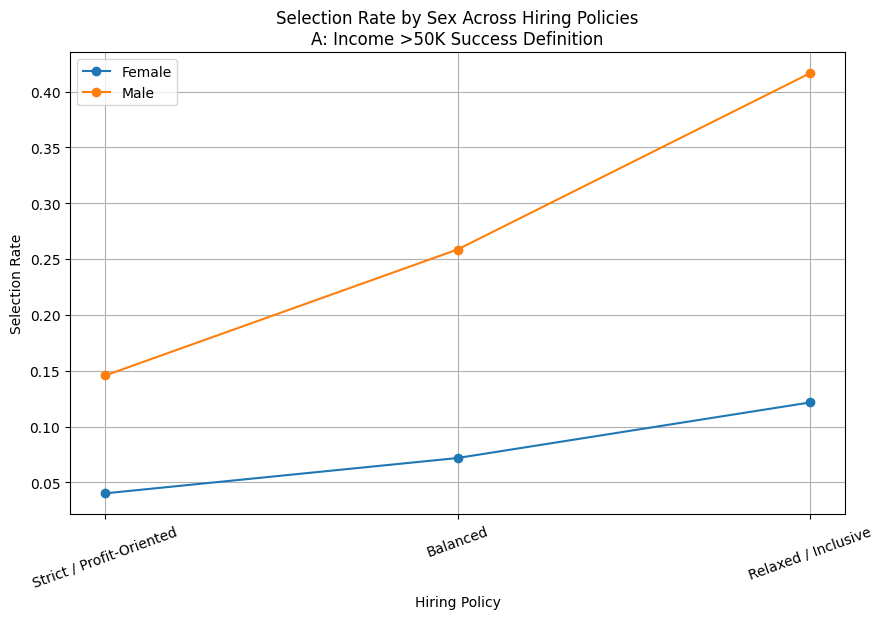

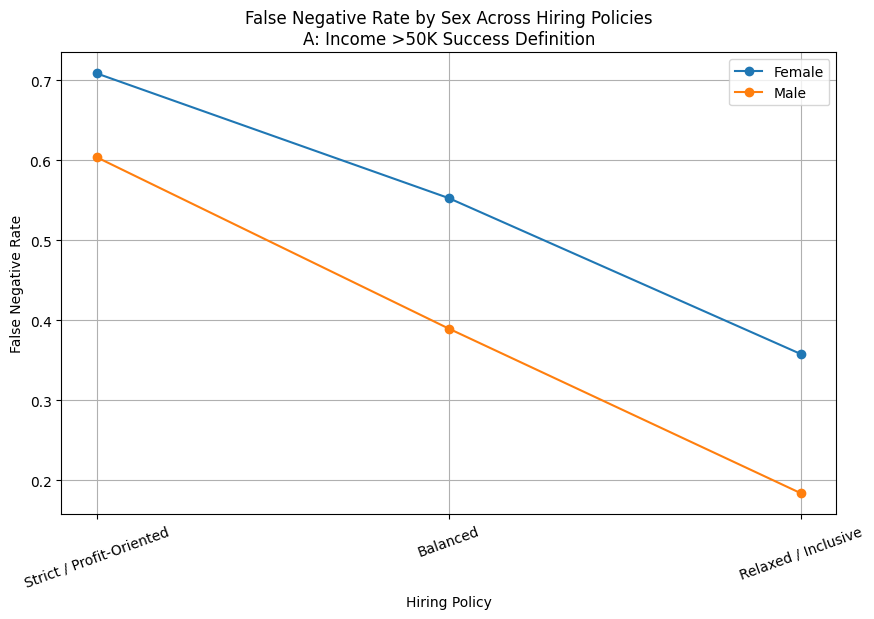

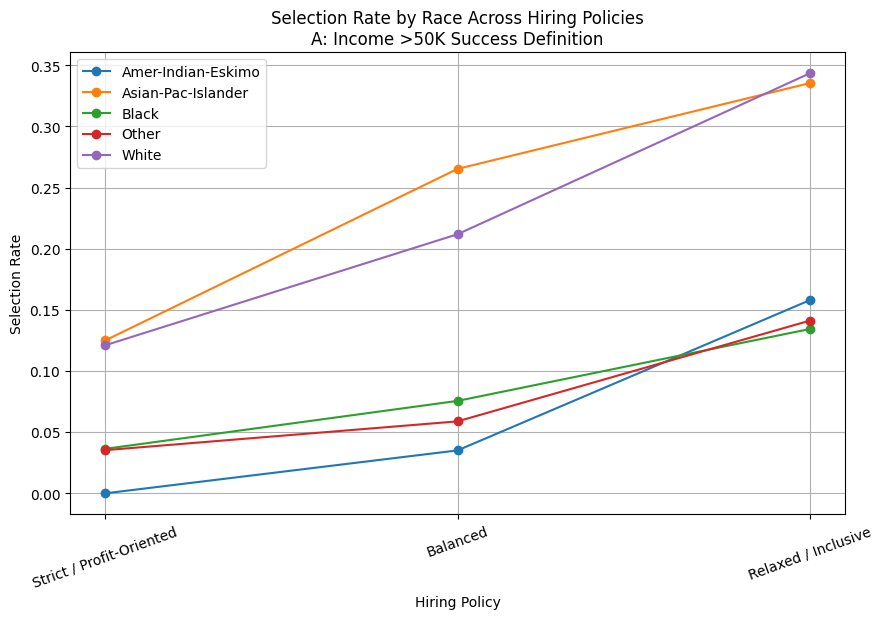

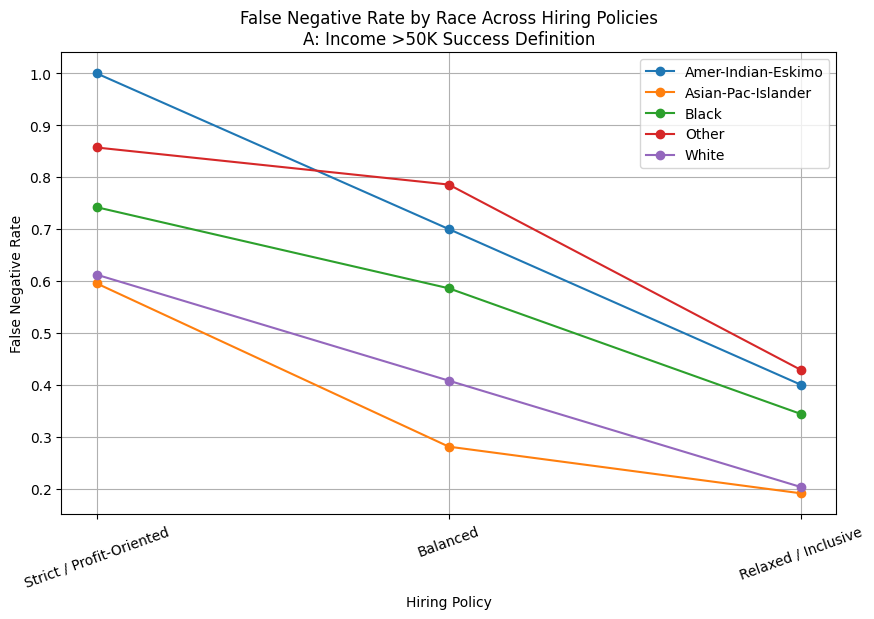

,experiment,threshold,accuracy,precision,recall,selection_rate,utility,sex_selection_gap,sex_fnr_gap,race_selection_gap,race_fnr_gap
0,A: Income >50K Success Definition,0.1,0.714399,0.462876,0.950036,0.508668,2165.0,0.416237,0.090221,0.250139,0.152753
1,A: Income >50K Success Definition,0.2,0.786662,0.542744,0.883655,0.403503,2703.0,0.367179,0.161000,0.240628,0.185982
2,A: Income >50K Success Definition,0.3,0.823368,0.611280,0.789079,0.319919,2720.5,0.294760,0.173944,0.209032,0.237560
3,A: Income >50K Success Definition,0.4,0.840262,0.674248,0.687723,0.252786,2485.5,0.231931,0.162559,0.228979,0.489567
4,A: Income >50K Success Definition,0.5,0.844596,0.733990,0.584939,0.197506,2102.5,0.186720,0.163065,0.230156,0.504815
5,A: Income >50K Success Definition,0.6,0.840527,0.791254,0.484297,0.151689,1633.5,0.144729,0.141661,0.189024,0.573034
6,A: Income >50K Success Definition,0.7,0.829117,0.845787,0.379729,0.111268,1065.0,0.105536,0.104743,0.125000,0.404494
7,A: Income >50K Success Definition,0.8,0.810101,0.895054,0.264811,0.073324,367.0,0.068015,0.071865,0.079942,0.270207
8,A: Income >50K Success Definition,0.9,0.789846,0.947479,0.160956,0.042102,-298.5,0.037674,0.035792,0.048780,0.179775


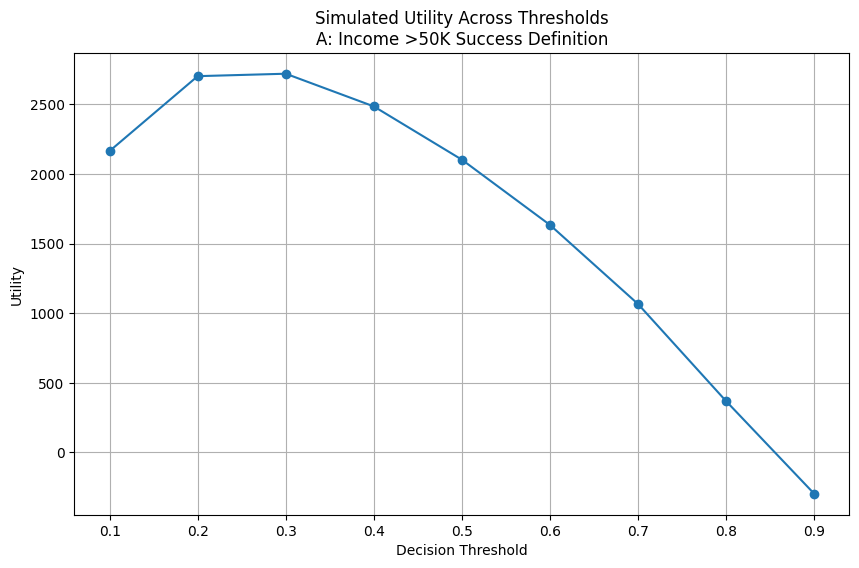

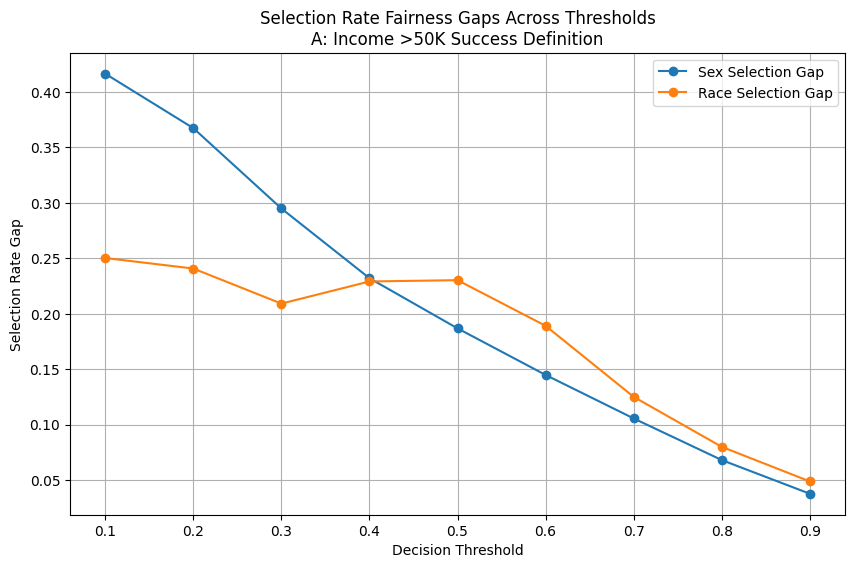

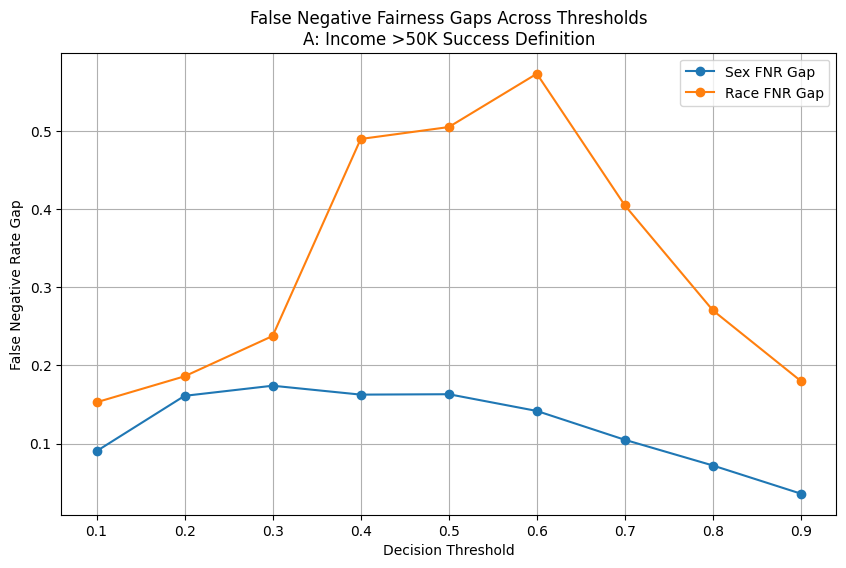

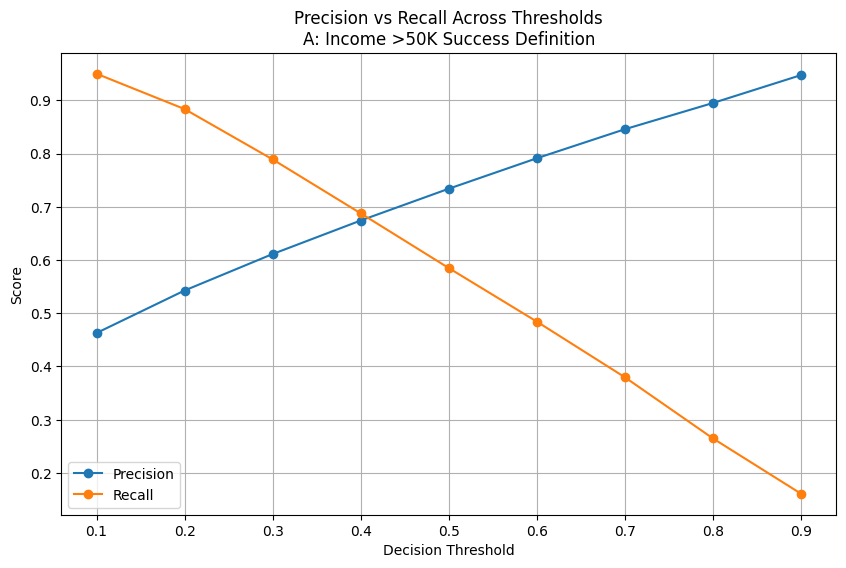

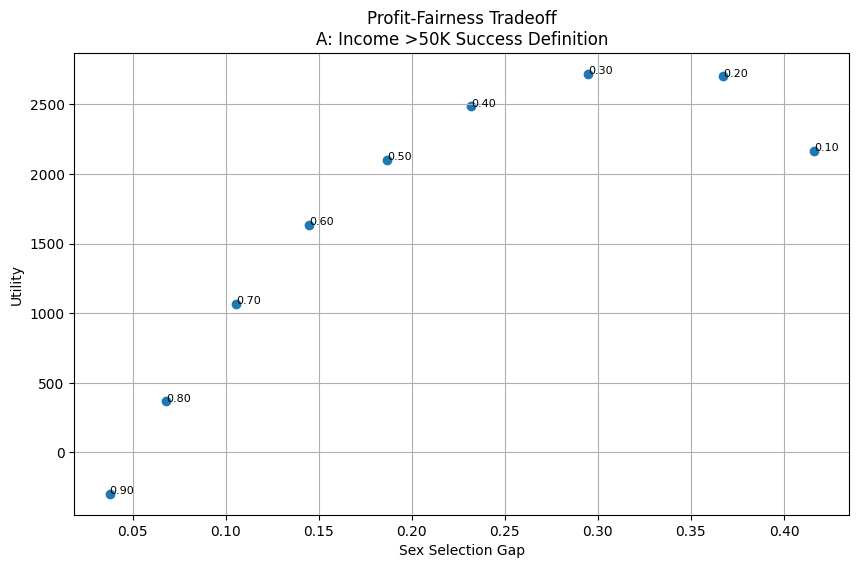


B: Composite Work-Readiness Success Definition
Positive class rate: 0.399053558002742
Feature columns used: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Default threshold 0.50 performance:
Accuracy: 0.9830178666194941
Precision: 0.9599659284497445
Recall: 0.999113475177305

Policy: Strict / Profit-Oriented

Fairness by sex:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Female,3653,1320,0.361347,1289,31,37,2296,0.013322,0.027903
1,Male,7653,3226,0.421534,3172,54,14,4413,0.012089,0.004394



Fairness by race:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Amer-Indian-Eskimo,101,27,0.267327,25,2,0,74,0.026316,0.000000
1,Asian-Pac-Islander,341,177,0.519062,175,2,4,160,0.012346,0.022346
2,Black,1042,259,0.248560,249,10,7,776,0.012723,0.027344
3,Other,96,20,0.208333,20,0,2,74,0.000000,0.090909
4,White,9726,4063,0.417746,3992,71,38,5625,0.012465,0.009429



Intersectional fairness by race + sex:


...

,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Female,3653,1481,0.405420,1326,155,0,2172,0.066609,0.0
1,Male,7653,3313,0.432902,3186,127,0,4340,0.028431,0.0



Fairness by race:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Amer-Indian-Eskimo,101,28,0.277228,25,3,0,73,0.039474,0.0
1,Asian-Pac-Islander,341,190,0.557185,179,11,0,151,0.067901,0.0
2,Black,1042,293,0.281190,256,37,0,749,0.047074,0.0
3,Other,96,24,0.250000,22,2,0,72,0.027027,0.0
4,White,9726,4259,0.437898,4030,229,0,5467,0.040204,0.0



Intersectional fairness by race + sex:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
3,Asian-Pac-Islander | Male,220,127,0.577273,121,6,0,93,0.060606,0.0
2,Asian-Pac-Islander | Female,121,63,0.520661,58,5,0,58,0.079365,0.0
9,White | Male,6802,3022,0.444281,2913,109,0,3780,0.028028,0.0
8,White | Female,2924,1237,0.423051,1117,120,0,1687,0.066408,0.0
0,Amer-Indian-Eskimo | Female,48,16,0.333333,13,3,0,32,0.085714,0.0
4,Black | Female,522,156,0.298851,130,26,0,366,0.066327,0.0
5,Black | Male,520,137,0.263462,126,11,0,383,0.027919,0.0
7,Other | Male,58,15,0.258621,14,1,0,43,0.022727,0.0
6,Other | Female,38,9,0.236842,8,1,0,29,0.033333,0.0
1,Amer-Indian-Eskimo | Male,53,12,0.226415,12,0,0,41,0.000000,0.0


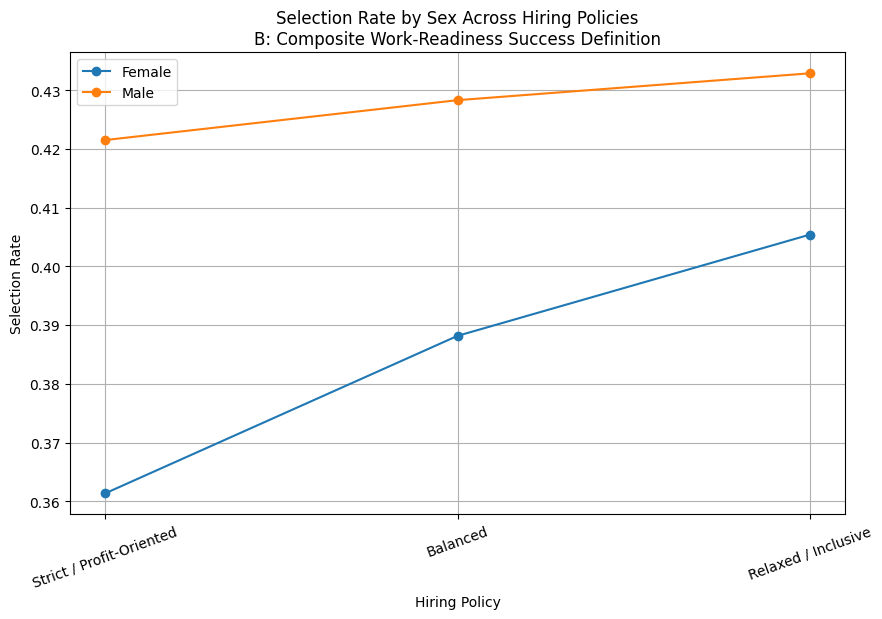

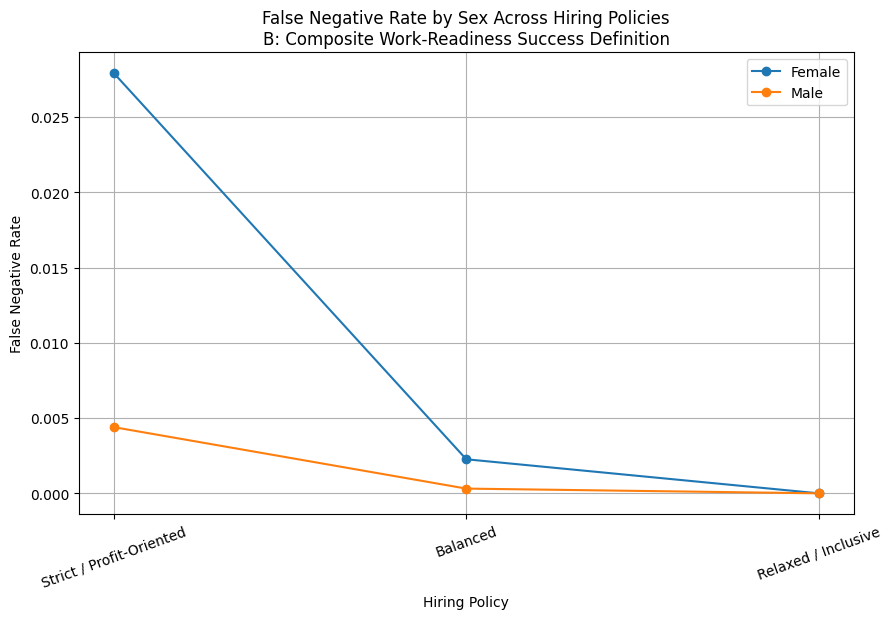

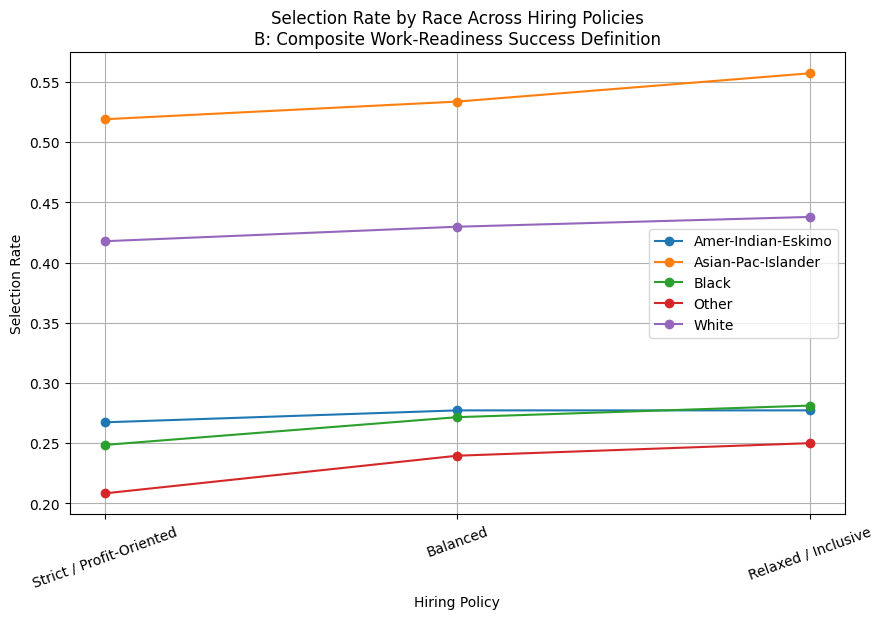

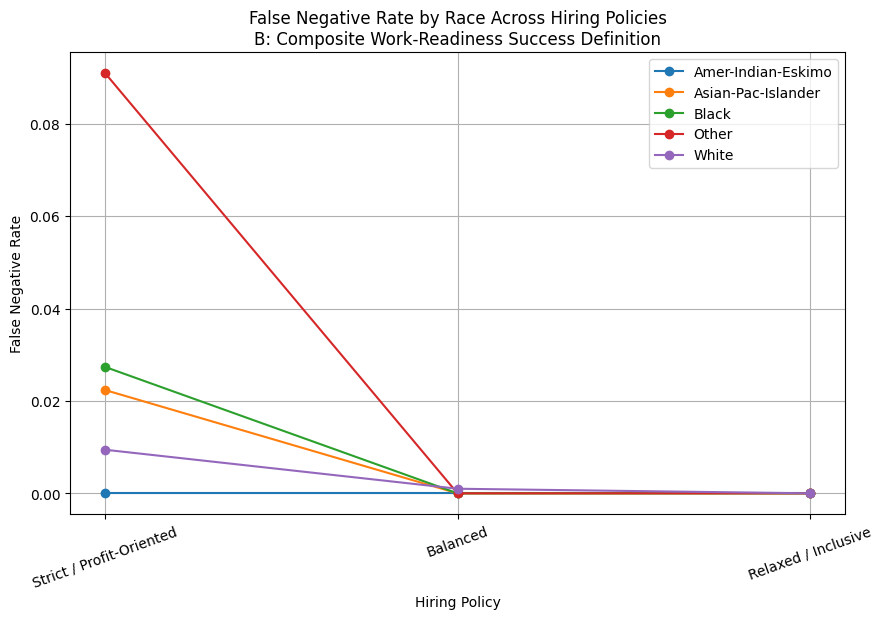

,experiment,threshold,accuracy,precision,recall,selection_rate,utility,sex_selection_gap,sex_fnr_gap,race_selection_gap,race_fnr_gap
0,B: Composite Work-Readiness Success Definition,0.1,0.965593,0.920628,1.000000,0.433487,8635.0,0.015985,0.000000,0.295149,0.000000
1,B: Composite Work-Readiness Success Definition,0.2,0.970547,0.931269,1.000000,0.428534,8691.0,0.022418,0.000000,0.310117,0.000000
2,B: Composite Work-Readiness Success Definition,0.3,0.975057,0.941176,1.000000,0.424023,8742.0,0.027482,0.000000,0.307185,0.000000
3,B: Composite Work-Readiness Success Definition,0.4,0.978595,0.949285,0.999778,0.420308,8780.5,0.031700,0.000754,0.295455,0.000248
4,B: Composite Work-Readiness Success Definition,0.5,0.983018,0.959966,0.999113,0.415355,8826.0,0.040155,0.001949,0.294141,0.000993
5,B: Composite Work-Readiness Success Definition,0.6,0.986467,0.970633,0.996232,0.409606,8845.5,0.048242,0.006412,0.295760,0.011173
6,B: Composite Work-Readiness Success Definition,0.7,0.987971,0.981302,0.988697,0.402087,8811.5,0.060187,0.023509,0.310728,0.090909
7,B: Composite Work-Readiness Success Definition,0.8,0.975588,0.993476,0.945035,0.379621,8376.0,0.097366,0.118675,0.299304,0.181818
8,B: Composite Work-Readiness Success Definition,0.9,0.922431,0.998902,0.806516,0.322218,6837.5,0.129034,0.226891,0.277768,0.170566


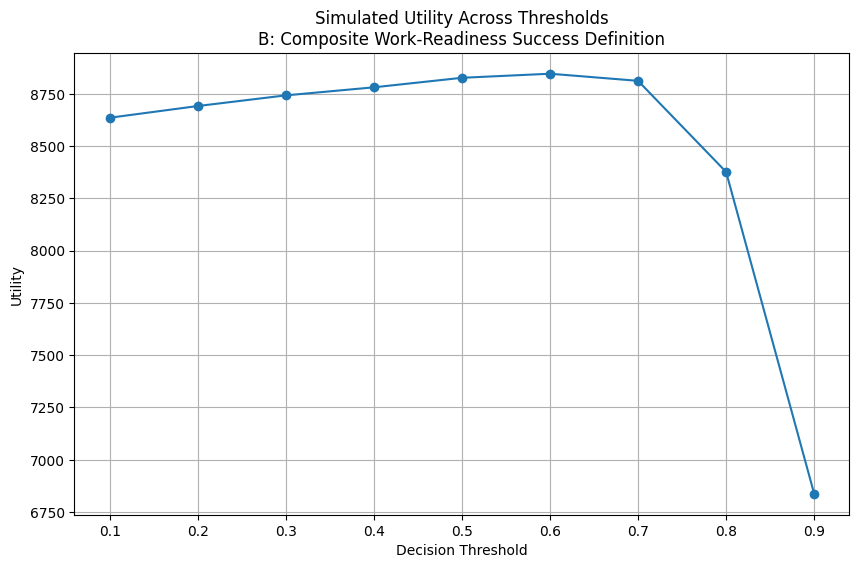

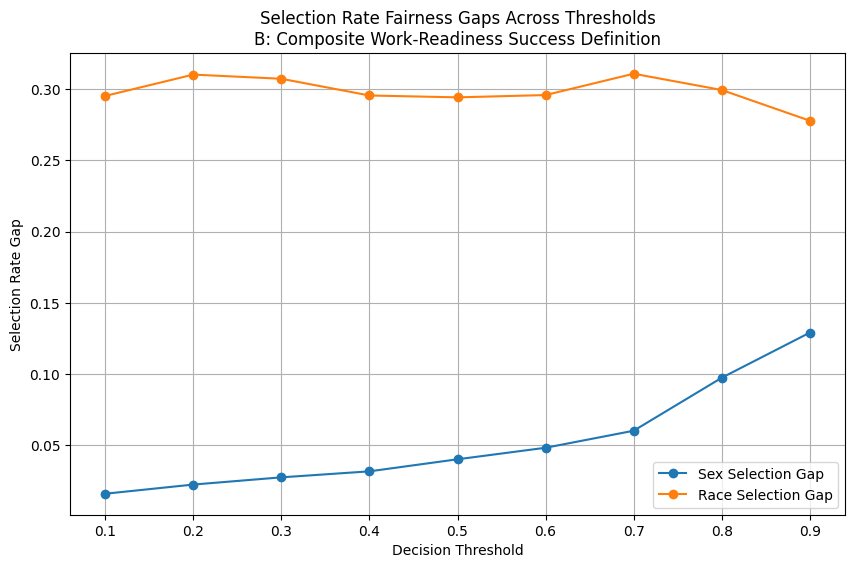

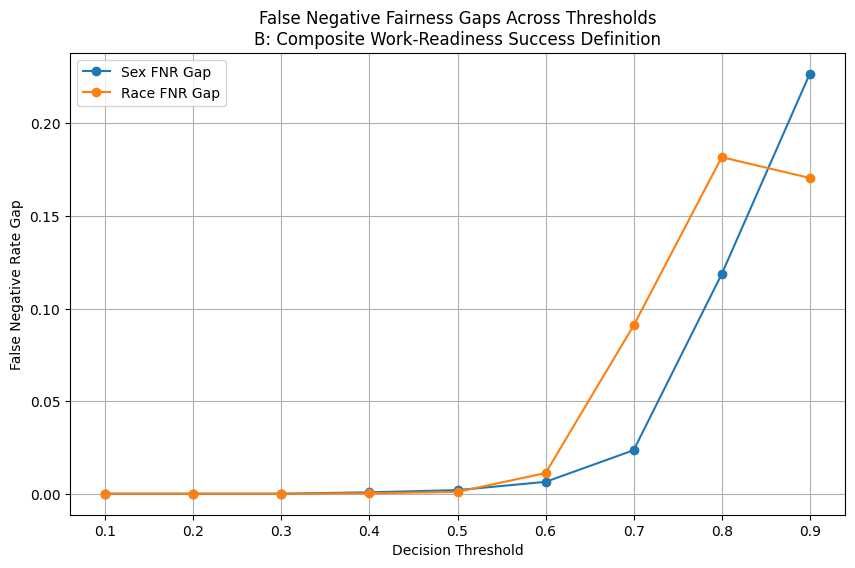

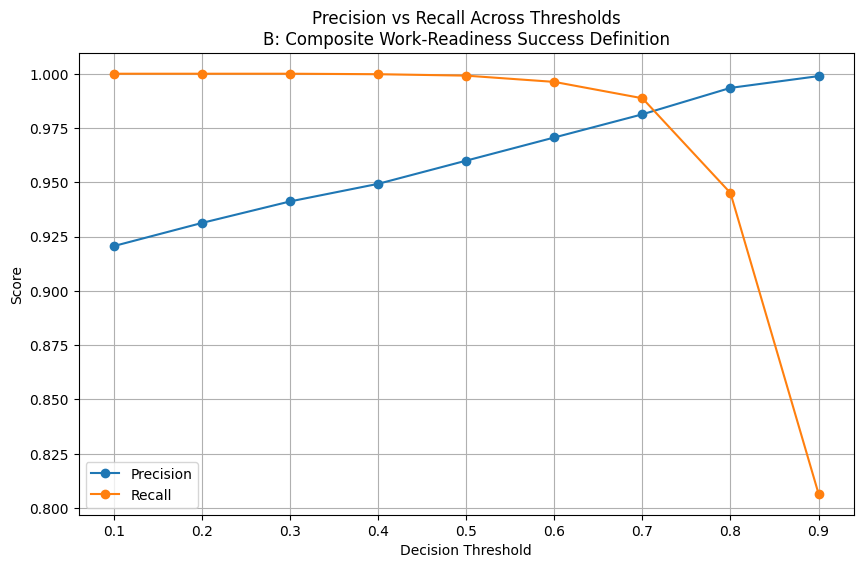

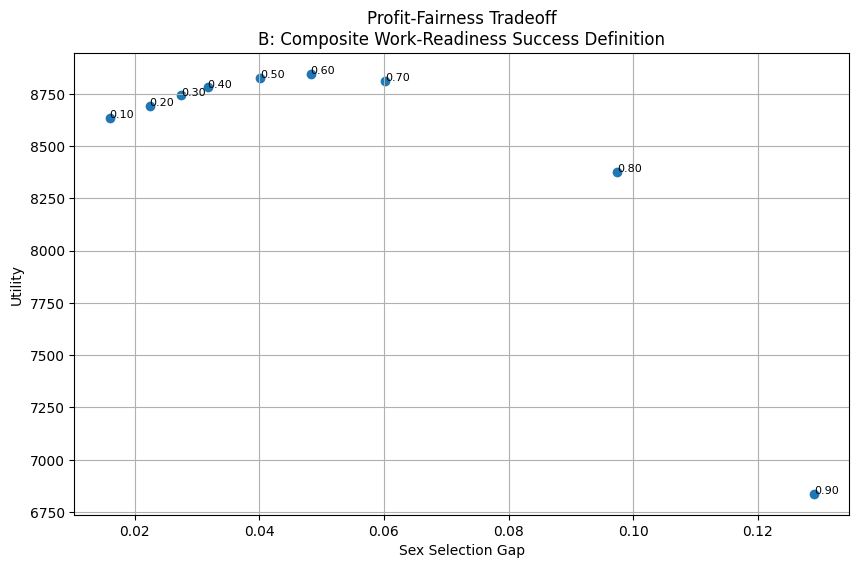


C: Income >50K Without Wealth Signals
Positive class rate: 0.2478439697492371
Feature columns used: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'hours-per-week', 'native-country']

Default threshold 0.50 performance:
Accuracy: 0.8266407217406687
Precision: 0.6894689468946895
Recall: 0.5467523197715917

Policy: Strict / Profit-Oriented

Fairness by sex:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Female,3700,130,0.035135,97,33,339,3231,0.01011,0.777523
1,Male,7606,960,0.126216,770,190,1596,5050,0.03626,0.674556



Fairness by race:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Amer-Indian-Eskimo,114,0,0.000000,0,0,10,104,0.000000,1.000000
1,Asian-Pac-Islander,328,44,0.134146,36,8,53,231,0.033473,0.595506
2,Black,1072,32,0.029851,26,6,102,938,0.006356,0.796875
3,Other,85,1,0.011765,1,0,13,71,0.000000,0.928571
4,White,9707,1013,0.104358,804,209,1757,6937,0.029247,0.686060



Intersectional fairness by race + sex:


...

,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Female,3700,463,0.125135,271,192,165,3072,0.058824,0.378440
1,Male,7606,3349,0.440310,1936,1413,430,3827,0.269656,0.181741



Fairness by race:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
0,Amer-Indian-Eskimo,114,20,0.175439,4,16,6,88,0.153846,0.600000
1,Asian-Pac-Islander,328,114,0.347561,74,40,15,199,0.167364,0.168539
2,Black,1072,153,0.142724,89,64,39,880,0.067797,0.304688
3,Other,85,9,0.105882,6,3,8,68,0.042254,0.571429
4,White,9707,3516,0.362213,2034,1482,527,5664,0.207389,0.205779



Intersectional fairness by race + sex:


,group,sample_size,selected_count,selection_rate,TP_good_hires,FP_bad_hires,FN_missed_good_candidates,TN_correct_rejections,false_positive_rate,false_negative_rate
3,Asian-Pac-Islander | Male,217,100,0.460829,65,35,6,111,0.239726,0.084507
9,White | Male,6721,3095,0.460497,1787,1308,386,3240,0.287599,0.177635
1,Amer-Indian-Eskimo | Male,76,19,0.250000,4,15,6,51,0.227273,0.600000
5,Black | Male,532,127,0.238722,75,52,25,380,0.120370,0.250000
8,White | Female,2986,421,0.140991,247,174,141,2424,0.066975,0.363402
7,Other | Male,60,8,0.133333,5,3,7,45,0.062500,0.583333
2,Asian-Pac-Islander | Female,111,14,0.126126,9,5,9,88,0.053763,0.500000
4,Black | Female,540,26,0.048148,14,12,14,500,0.023438,0.500000
6,Other | Female,25,1,0.040000,1,0,1,23,0.000000,0.500000
0,Amer-Indian-Eskimo | Female,38,1,0.026316,0,1,0,37,0.026316,NaN


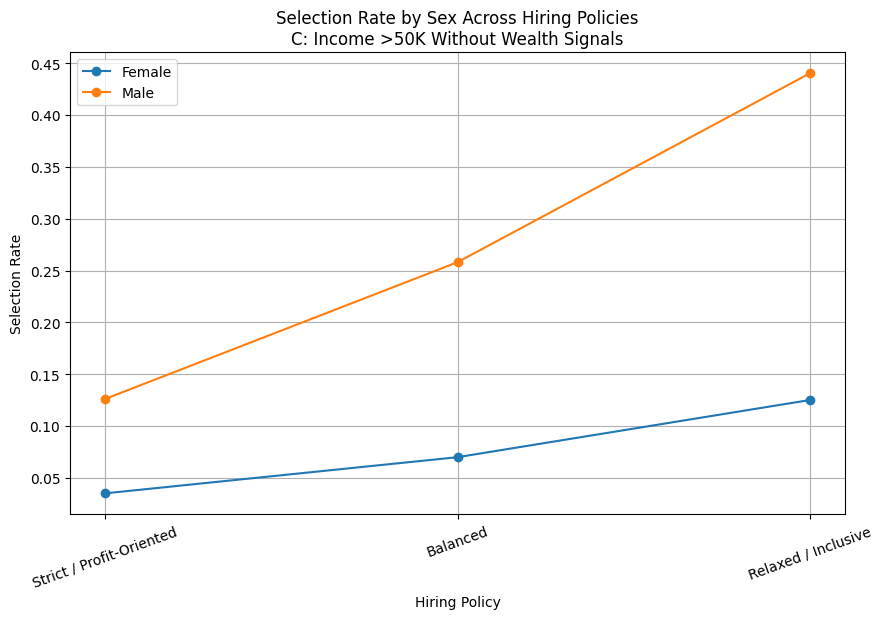

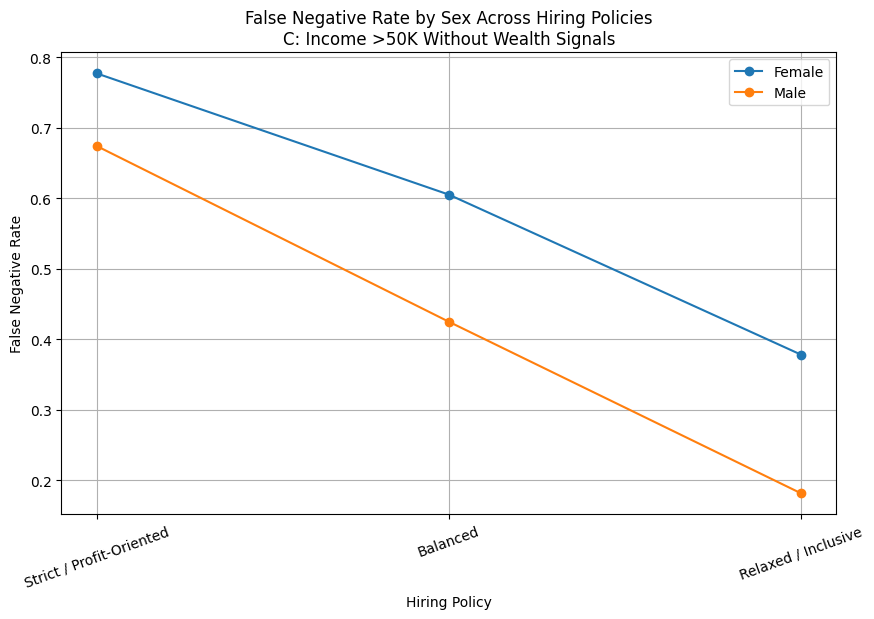

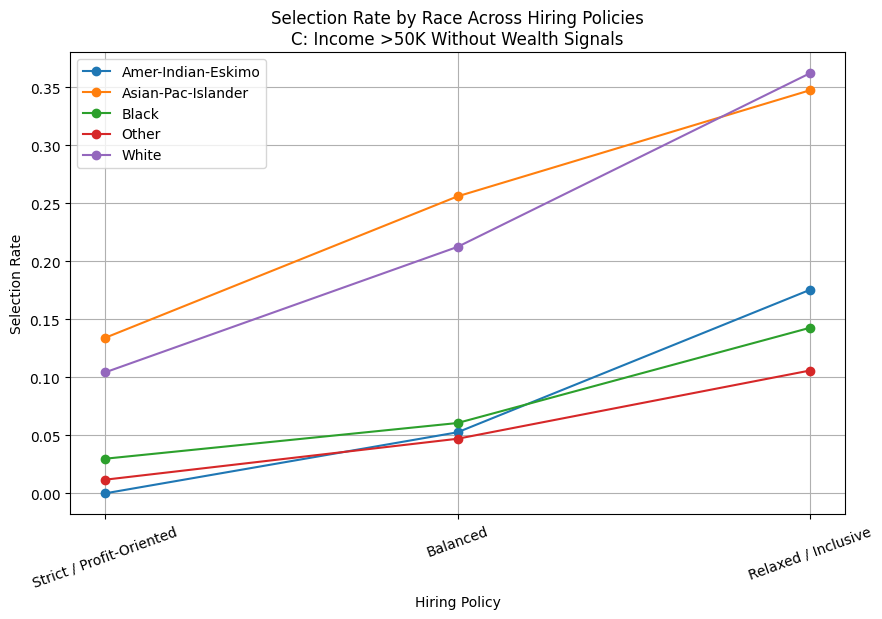

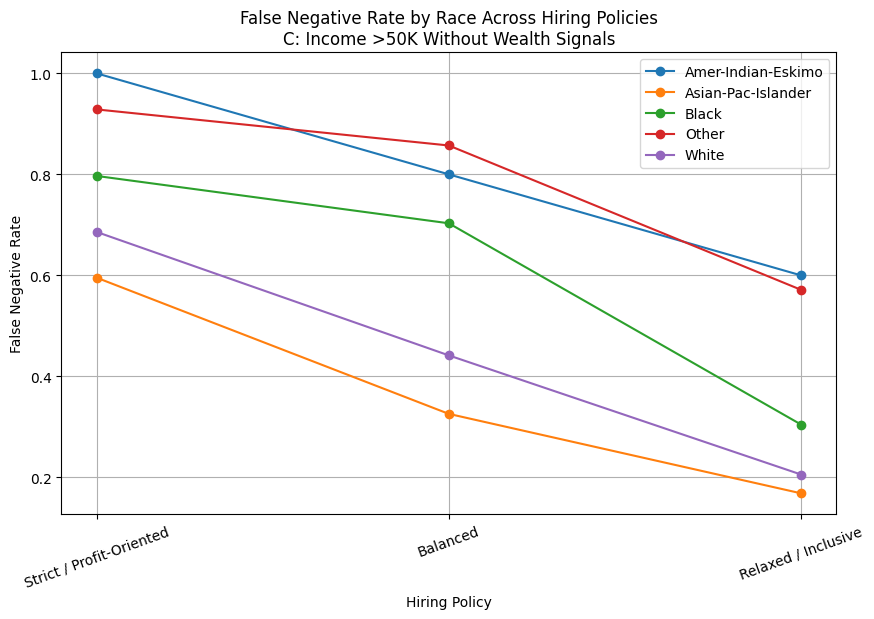

,experiment,threshold,accuracy,precision,recall,selection_rate,utility,sex_selection_gap,sex_fnr_gap,race_selection_gap,race_fnr_gap
0,C: Income >50K Without Wealth Signals,0.1,0.686715,0.439245,0.954675,0.538652,1871.5,0.405768,0.087567,0.285279,0.243934
1,C: Income >50K Without Wealth Signals,0.2,0.765434,0.515618,0.883655,0.424730,2463.0,0.382262,0.190879,0.263810,0.316506
2,C: Income >50K Without Wealth Signals,0.3,0.805413,0.578961,0.787652,0.337166,2511.5,0.315175,0.196699,0.256330,0.431461
3,C: Income >50K Without Wealth Signals,0.4,0.824164,0.639575,0.665596,0.257916,2210.5,0.246788,0.190679,0.243006,0.527287
4,C: Income >50K Without Wealth Signals,0.5,0.826641,0.689469,0.546752,0.196533,1739.0,0.188086,0.180314,0.209039,0.531300
5,C: Income >50K Without Wealth Signals,0.6,0.822218,0.742945,0.432191,0.144171,1207.5,0.142392,0.158724,0.187099,0.452648
6,C: Income >50K Without Wealth Signals,0.7,0.809128,0.795413,0.309422,0.096409,543.5,0.091081,0.102967,0.134146,0.404494
7,C: Income >50K Without Wealth Signals,0.8,0.787635,0.845095,0.175232,0.051389,-263.5,0.051077,0.068995,0.067073,0.213483
8,C: Income >50K Without Wealth Signals,0.9,0.762427,0.881579,0.047823,0.013444,-1084.0,0.014360,0.021325,0.018293,0.067416


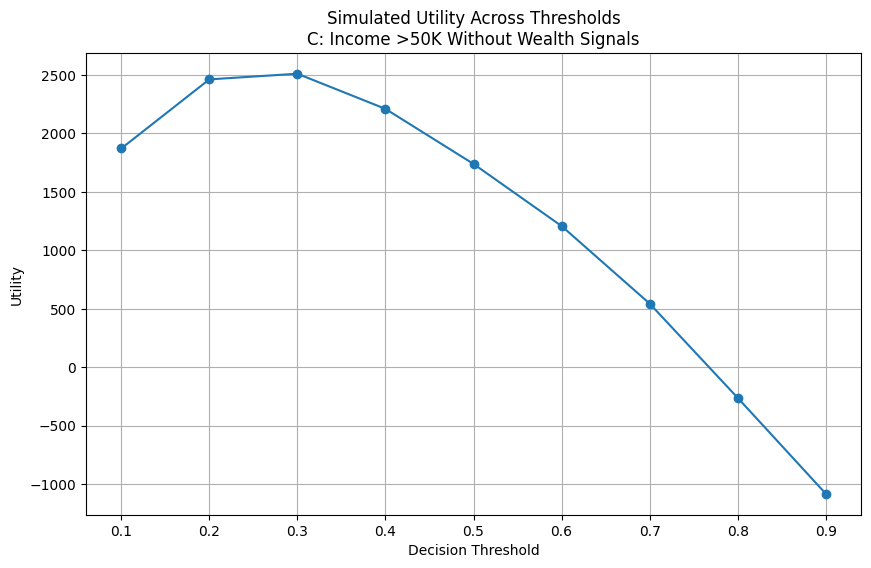

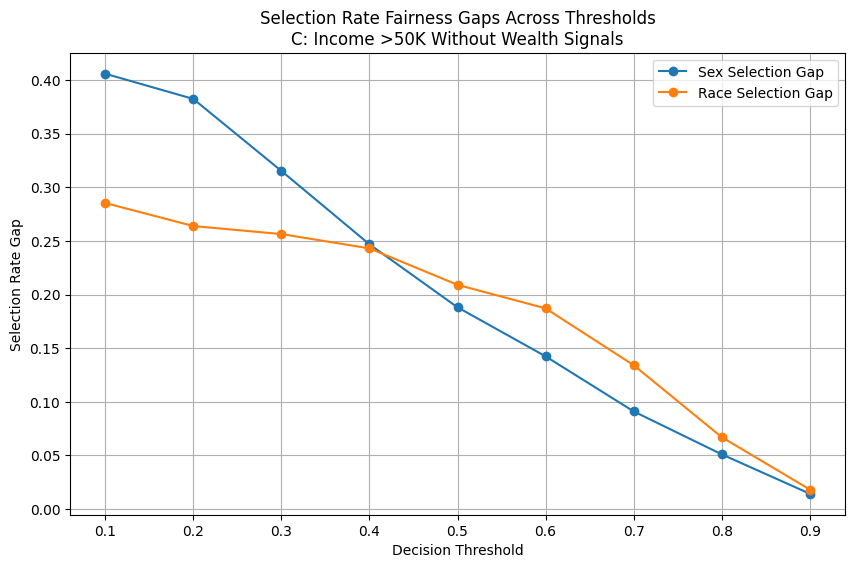

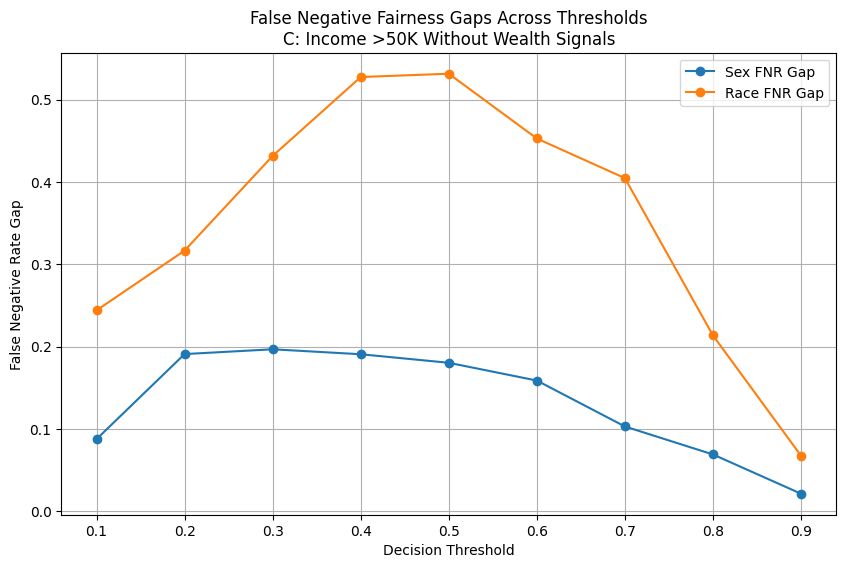

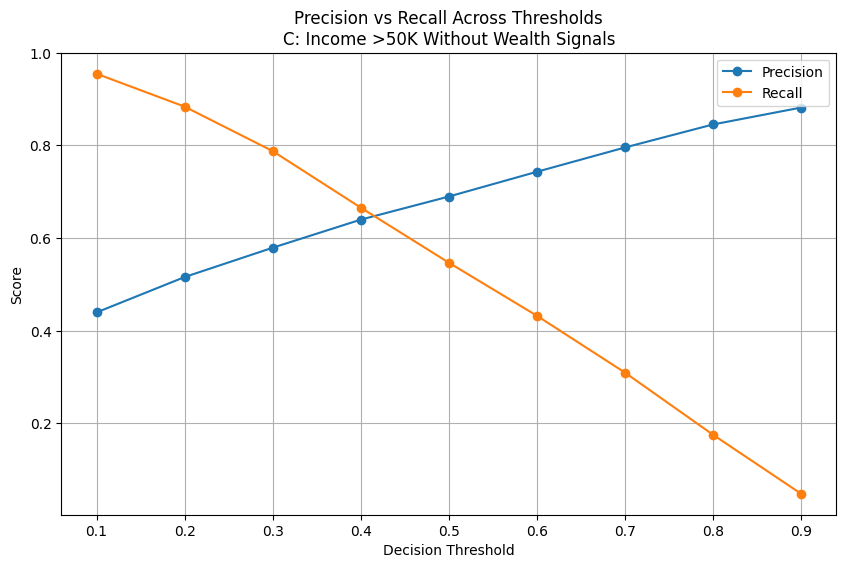

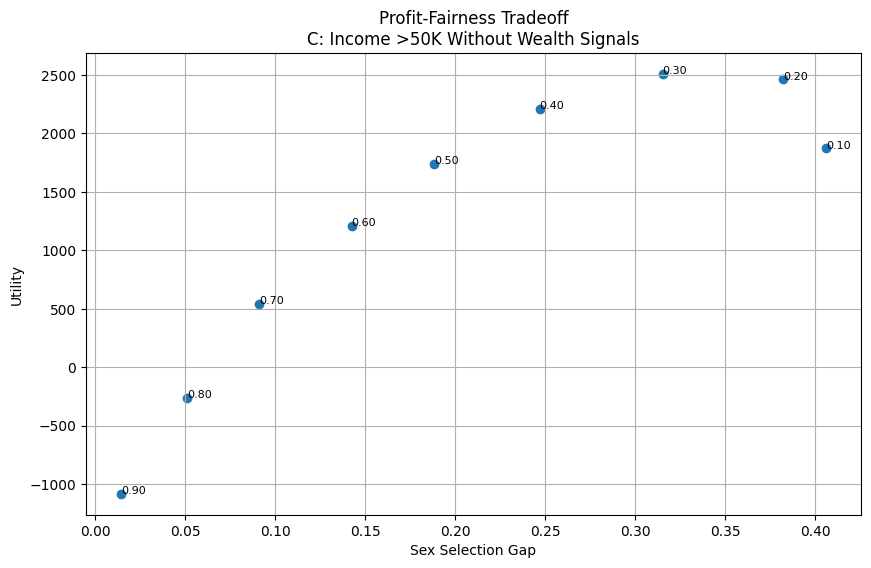

In [8]:
# Experiment A:
# Original model where "good hire" = income >50K
results_income, tradeoff_income = run_experiment(
    base_df=df,
    target_column="income_success",
    experiment_name="A: Income >50K Success Definition"
)

# Experiment B:
# Alternative model where "good hire" = composite work-readiness score
results_composite, tradeoff_composite = run_experiment(
    base_df=df,
    target_column="composite_success",
    experiment_name="B: Composite Work-Readiness Success Definition"
)

# Experiment C:
# Original income success target, but model cannot use wealth signals
results_no_wealth, tradeoff_no_wealth = run_experiment(
    base_df=df,
    target_column="income_success",
    experiment_name="C: Income >50K Without Wealth Signals",
    drop_columns=["capital-gain", "capital-loss"]
)

In [9]:
# Combine all threshold results into one dataframe
all_tradeoffs = pd.concat(
    [tradeoff_income, tradeoff_composite, tradeoff_no_wealth],
    ignore_index=True
)

display(all_tradeoffs)

,experiment,threshold,accuracy,precision,recall,selection_rate,utility,sex_selection_gap,sex_fnr_gap,race_selection_gap,race_fnr_gap
0,A: Income >50K Success Definition,0.1,0.714399,0.462876,0.950036,0.508668,2165.0,0.416237,0.090221,0.250139,0.152753
1,A: Income >50K Success Definition,0.2,0.786662,0.542744,0.883655,0.403503,2703.0,0.367179,0.161000,0.240628,0.185982
2,A: Income >50K Success Definition,0.3,0.823368,0.611280,0.789079,0.319919,2720.5,0.294760,0.173944,0.209032,0.237560
3,A: Income >50K Success Definition,0.4,0.840262,0.674248,0.687723,0.252786,2485.5,0.231931,0.162559,0.228979,0.489567
4,A: Income >50K Success Definition,0.5,0.844596,0.733990,0.584939,0.197506,2102.5,0.186720,0.163065,0.230156,0.504815
5,A: Income >50K Success Definition,0.6,0.840527,0.791254,0.484297,0.151689,1633.5,0.144729,0.141661,0.189024,0.573034
6,A: Income >50K Success Definition,0.7,0.829117,0.845787,0.379729,0.111268,1065.0,0.105536,0.104743,0.125000,0.404494
7,A: Income >50K Success Definition,0.8,0.810101,0.895054,0.264811,0.073324,367.0,0.068015,0.071865,0.079942,0.270207
8,A: Income >50K Success Definition,0.9,0.789846,0.947479,0.160956,0.042102,-298.5,0.037674,0.035792,0.048780,0.179775
9,B: Composite Work-Readiness Success Definition,0.1,0.965593,0.920628,1.000000,0.433487,8635.0,0.015985,0.000000,0.295149,0.000000


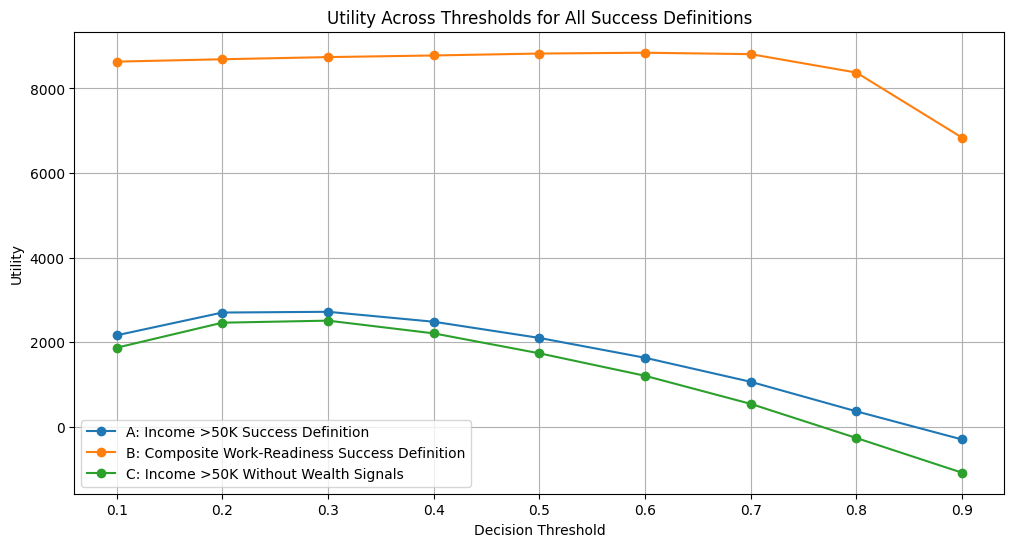

In [10]:
plt.figure(figsize=(12, 6))

for experiment in all_tradeoffs["experiment"].unique():
    temp = all_tradeoffs[all_tradeoffs["experiment"] == experiment]
    plt.plot(temp["threshold"], temp["utility"], marker="o", label=experiment)

plt.title("Utility Across Thresholds for All Success Definitions")
plt.xlabel("Decision Threshold")
plt.ylabel("Utility")
plt.legend()
plt.grid(True)
plt.show()

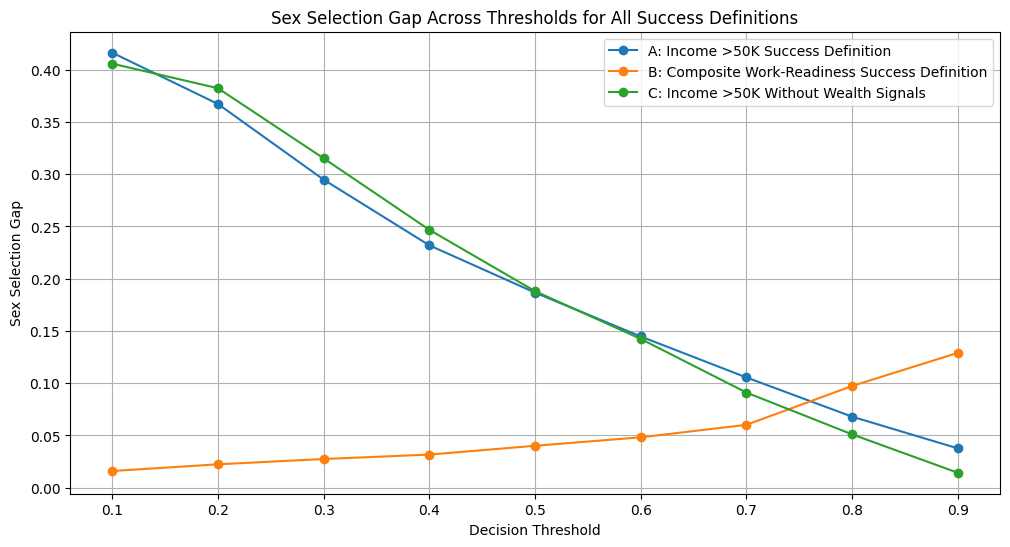

In [11]:
plt.figure(figsize=(12, 6))

for experiment in all_tradeoffs["experiment"].unique():
    temp = all_tradeoffs[all_tradeoffs["experiment"] == experiment]
    plt.plot(temp["threshold"], temp["sex_selection_gap"], marker="o", label=experiment)

plt.title("Sex Selection Gap Across Thresholds for All Success Definitions")
plt.xlabel("Decision Threshold")
plt.ylabel("Sex Selection Gap")
plt.legend()
plt.grid(True)
plt.show()

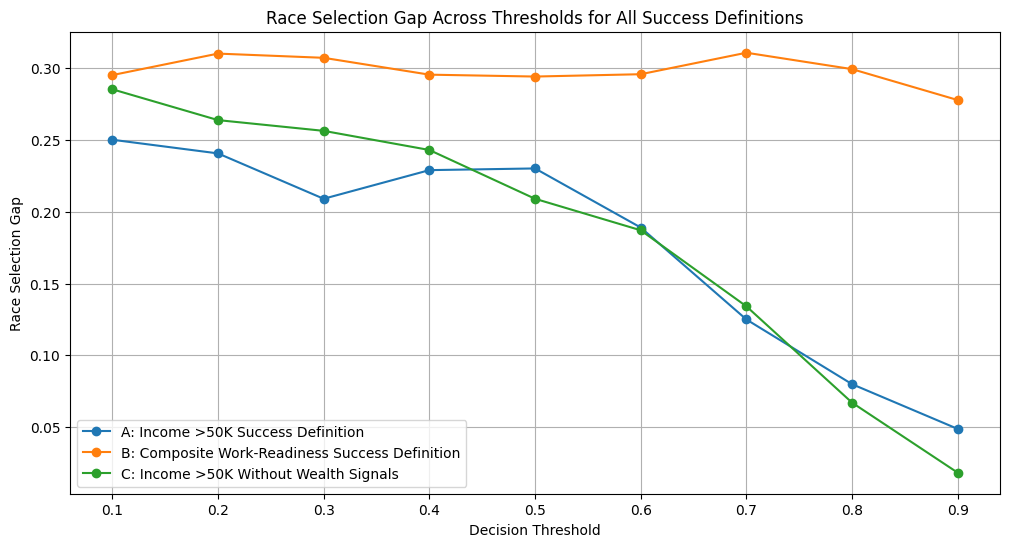

In [12]:
plt.figure(figsize=(12, 6))

for experiment in all_tradeoffs["experiment"].unique():
    temp = all_tradeoffs[all_tradeoffs["experiment"] == experiment]
    plt.plot(temp["threshold"], temp["race_selection_gap"], marker="o", label=experiment)

plt.title("Race Selection Gap Across Thresholds for All Success Definitions")
plt.xlabel("Decision Threshold")
plt.ylabel("Race Selection Gap")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
summary_rows = []

for experiment in all_tradeoffs["experiment"].unique():
    temp = all_tradeoffs[all_tradeoffs["experiment"] == experiment]

    # Avoid unrealistic thresholds that hire almost nobody
    valid = temp[
        (temp["selection_rate"] >= 0.10) &
        (temp["recall"] >= 0.40)
    ]

    best_utility = valid.loc[valid["utility"].idxmax()]
    best_sex_fairness = valid.loc[valid["sex_selection_gap"].idxmin()]
    best_race_fairness = valid.loc[valid["race_selection_gap"].idxmin()]

    summary_rows.append({
        "experiment": experiment,

        "best_utility_threshold": best_utility["threshold"],
        "best_utility": best_utility["utility"],
        "sex_gap_at_best_utility": best_utility["sex_selection_gap"],
        "race_gap_at_best_utility": best_utility["race_selection_gap"],

        "best_sex_fairness_threshold": best_sex_fairness["threshold"],
        "best_sex_selection_gap": best_sex_fairness["sex_selection_gap"],

        "best_race_fairness_threshold": best_race_fairness["threshold"],
        "best_race_selection_gap": best_race_fairness["race_selection_gap"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,experiment,best_utility_threshold,best_utility,sex_gap_at_best_utility,race_gap_at_best_utility,best_sex_fairness_threshold,best_sex_selection_gap,best_race_fairness_threshold,best_race_selection_gap
0,A: Income >50K Success Definition,0.3,2720.5,0.294760,0.209032,0.6,0.144729,0.6,0.189024
1,B: Composite Work-Readiness Success Definition,0.6,8845.5,0.048242,0.295760,0.1,0.015985,0.9,0.277768
2,C: Income >50K Without Wealth Signals,0.3,2511.5,0.315175,0.256330,0.6,0.142392,0.6,0.187099


In [14]:
print("MAIN PROJECT INTERPRETATION")
print("-" * 80)

print(
    "This project compares three definitions of candidate success and tests how threshold policies "
    "change both efficiency and fairness outcomes."
)

print(
    "\nThe key idea is that the model does not simply become fair or unfair by itself. "
    "Fairness depends on the success definition, the features allowed into the model, and the decision threshold."
)

for _, row in summary_df.iterrows():
    print("\nExperiment:", row["experiment"])
    print(f"Best utility threshold: {row['best_utility_threshold']:.2f}")
    print(f"Best utility: {row['best_utility']:.2f}")
    print(f"Sex gap at best utility: {row['sex_gap_at_best_utility']:.3f}")
    print(f"Race gap at best utility: {row['race_gap_at_best_utility']:.3f}")
    print(f"Best sex fairness threshold: {row['best_sex_fairness_threshold']:.2f}")
    print(f"Best race fairness threshold: {row['best_race_fairness_threshold']:.2f}")

print(
    "\nOverall conclusion: AI hiring bias is not only caused by the model. "
    "It is also shaped by how success is defined and how the organization chooses to deploy the model. "
    "Different definitions of a 'good hire' produce different fairness outcomes, and different thresholds "
    "create different tradeoffs between utility and fairness."
)

MAIN PROJECT INTERPRETATION
--------------------------------------------------------------------------------
This project compares three definitions of candidate success and tests how threshold policies change both efficiency and fairness outcomes.

The key idea is that the model does not simply become fair or unfair by itself. Fairness depends on the success definition, the features allowed into the model, and the decision threshold.

Experiment: A: Income >50K Success Definition
Best utility threshold: 0.30
Best utility: 2720.50
Sex gap at best utility: 0.295
Race gap at best utility: 0.209
Best sex fairness threshold: 0.60
Best race fairness threshold: 0.60

Experiment: B: Composite Work-Readiness Success Definition
Best utility threshold: 0.60
Best utility: 8845.50
Sex gap at best utility: 0.048
Race gap at best utility: 0.296
Best sex fairness threshold: 0.10
Best race fairness threshold: 0.90

Experiment: C: Income >50K Without Wealth Signals
Best utility threshold: 0.30
Best uti

BEST OVERALL THRESHOLD (ACROSS ALL DEFINITIONS):


,2
threshold,0.300000
utility_norm,0.982819
sex_gap_norm,0.516451
race_gap_norm,0.859973
recall_norm,0.870613
precision_norm,0.294872
selection_rate,0.360369
fairness_penalty,0.688212
composite_score,0.447848


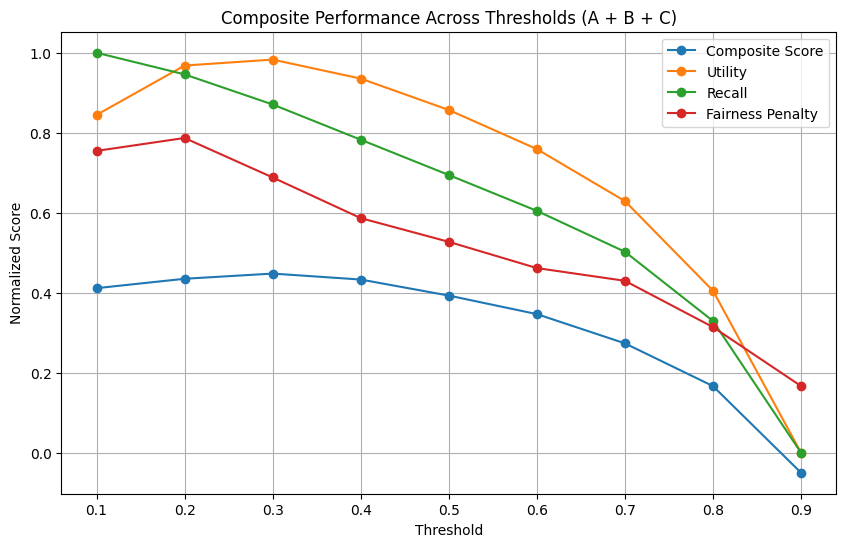

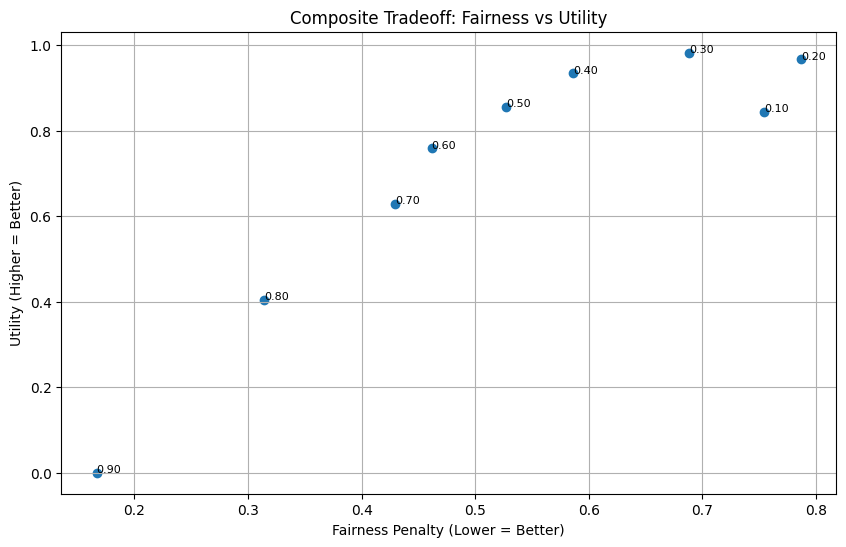

In [15]:
# ================================
# COMPOSITE ANALYSIS ACROSS A, B, C
# ================================

# Combine all tradeoff data
all_tradeoffs = pd.concat(
    [tradeoff_income, tradeoff_composite, tradeoff_no_wealth],
    ignore_index=True
)

# -------------------------------
# Normalize key metrics per experiment
# -------------------------------

def normalize_column(df, column):
    return (df[column] - df[column].min()) / (df[column].max() - df[column].min())

normalized_list = []

for experiment in all_tradeoffs["experiment"].unique():
    temp = all_tradeoffs[all_tradeoffs["experiment"] == experiment].copy()

    temp["utility_norm"] = normalize_column(temp, "utility")
    temp["sex_gap_norm"] = normalize_column(temp, "sex_selection_gap")
    temp["race_gap_norm"] = normalize_column(temp, "race_selection_gap")
    temp["recall_norm"] = normalize_column(temp, "recall")
    temp["precision_norm"] = normalize_column(temp, "precision")

    normalized_list.append(temp)

normalized_df = pd.concat(normalized_list)

# -------------------------------
# Aggregate by threshold
# -------------------------------

composite_df = normalized_df.groupby("threshold").agg({
    "utility_norm": "mean",
    "sex_gap_norm": "mean",
    "race_gap_norm": "mean",
    "recall_norm": "mean",
    "precision_norm": "mean",
    "selection_rate": "mean"
}).reset_index()

# -------------------------------
# Create composite score
# -------------------------------
# We want:
# - HIGH utility
# - HIGH recall (don’t miss good candidates)
# - LOW fairness gaps

composite_df["fairness_penalty"] = (
    composite_df["sex_gap_norm"] + composite_df["race_gap_norm"]
) / 2

# Final composite score (you can tweak weights)
composite_df["composite_score"] = (
    (0.4 * composite_df["utility_norm"]) +
    (0.3 * composite_df["recall_norm"]) -
    (0.3 * composite_df["fairness_penalty"])
)

# -------------------------------
# Find best threshold overall
# -------------------------------

best_row = composite_df.loc[composite_df["composite_score"].idxmax()]

print("BEST OVERALL THRESHOLD (ACROSS ALL DEFINITIONS):")
display(best_row)

# -------------------------------
# Plot composite results
# -------------------------------

plt.figure(figsize=(10, 6))

plt.plot(composite_df["threshold"], composite_df["composite_score"], marker="o", label="Composite Score")
plt.plot(composite_df["threshold"], composite_df["utility_norm"], marker="o", label="Utility")
plt.plot(composite_df["threshold"], composite_df["recall_norm"], marker="o", label="Recall")
plt.plot(composite_df["threshold"], composite_df["fairness_penalty"], marker="o", label="Fairness Penalty")

plt.title("Composite Performance Across Thresholds (A + B + C)")
plt.xlabel("Threshold")
plt.ylabel("Normalized Score")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Tradeoff scatter (FINAL GRAPH)
# -------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(composite_df["fairness_penalty"], composite_df["utility_norm"])

for _, row in composite_df.iterrows():
    plt.text(row["fairness_penalty"], row["utility_norm"], f"{row['threshold']:.2f}", fontsize=8)

plt.title("Composite Tradeoff: Fairness vs Utility")
plt.xlabel("Fairness Penalty (Lower = Better)")
plt.ylabel("Utility (Higher = Better)")
plt.grid(True)
plt.show()

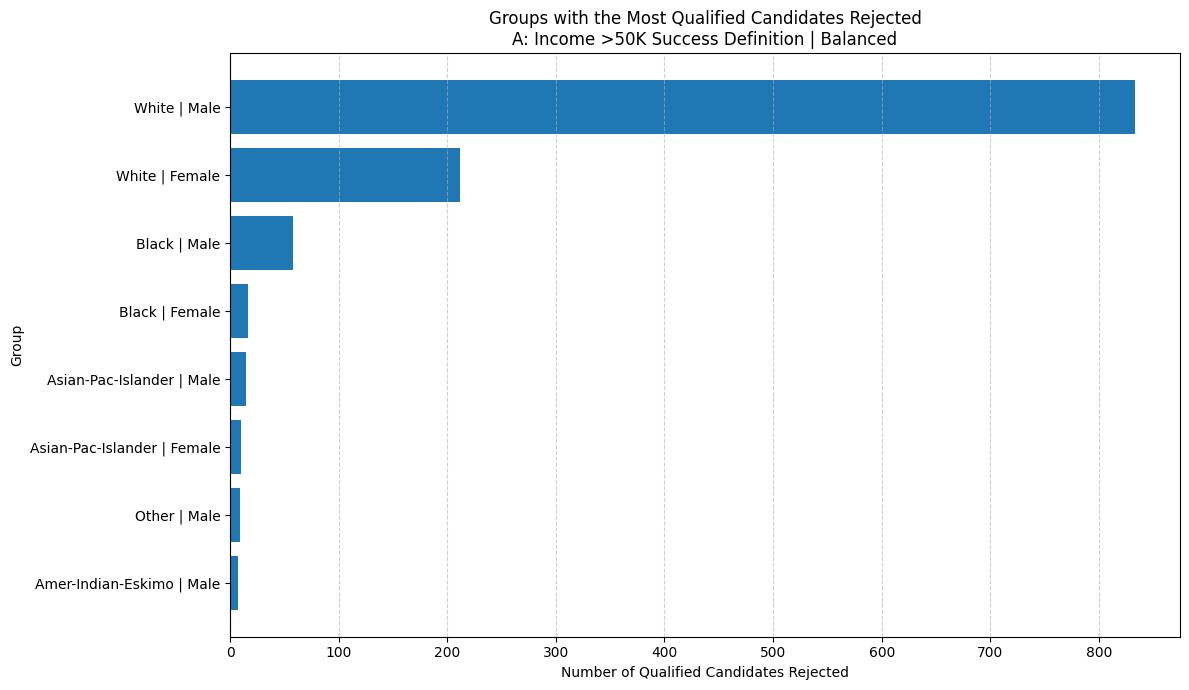

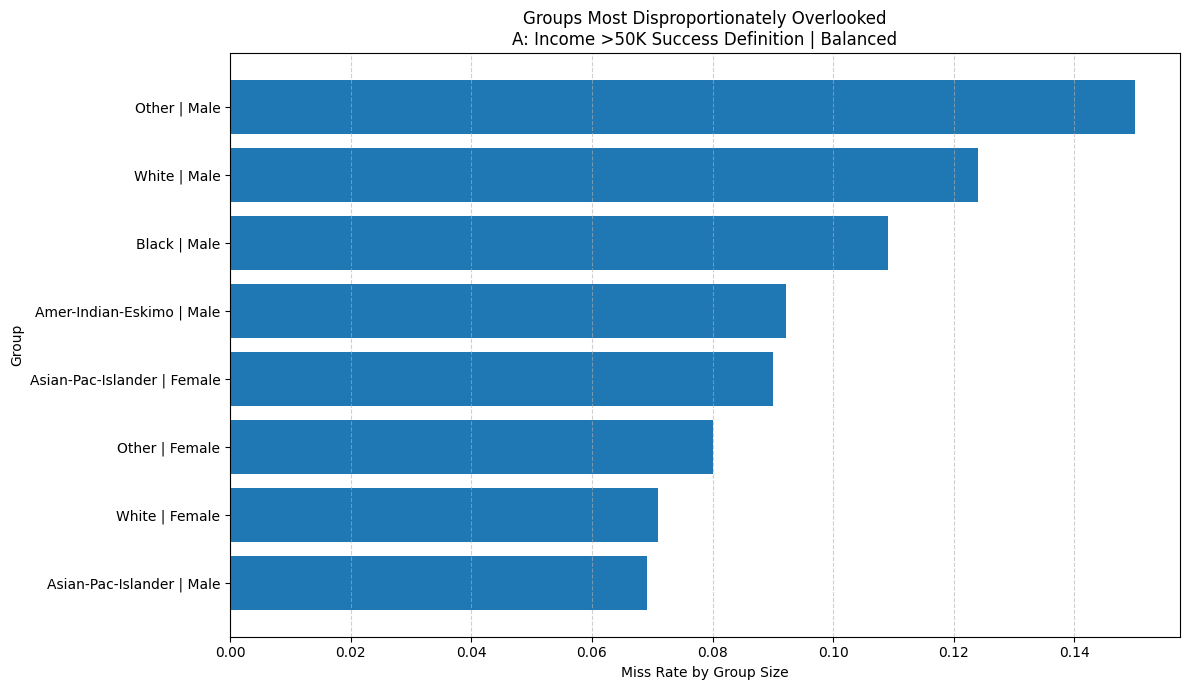

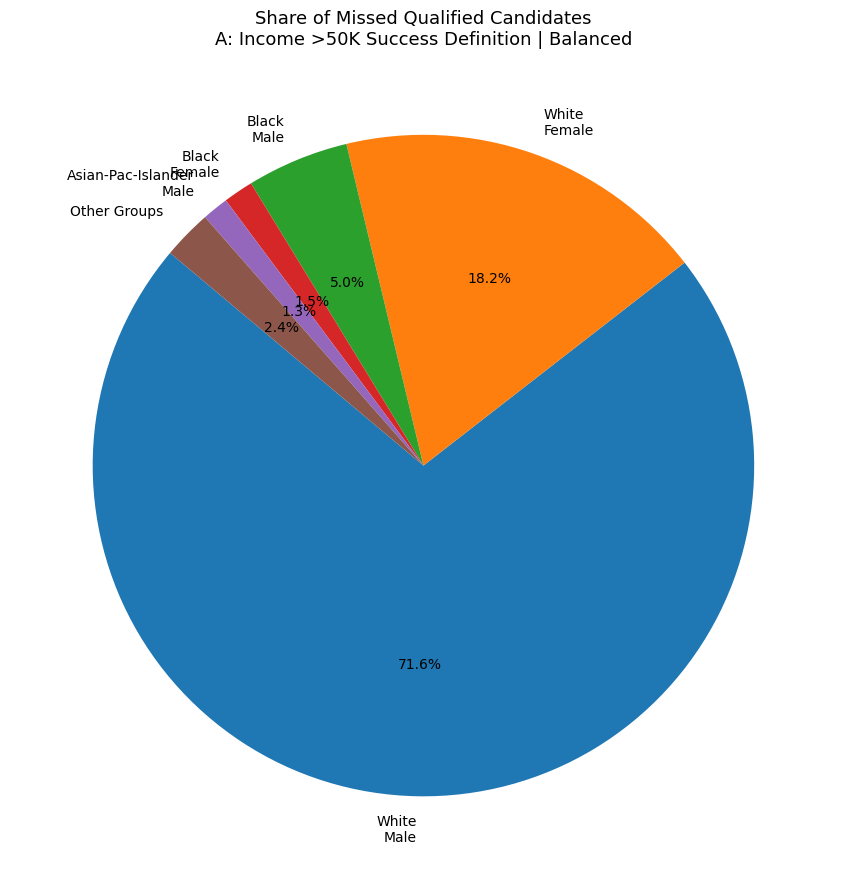

TOP MARGINALIZED GROUPS: A: Income >50K Success Definition | Balanced


,group,sample_size,selected_count,selection_rate,FN_missed_good_candidates,false_negative_rate,miss_rate_by_group_size
7,Other | Male,60,5,0.083333,9,0.750000,0.150000
9,White | Male,6721,1817,0.270347,833,0.383341,0.123940
5,Black | Male,532,66,0.124060,58,0.580000,0.109023
1,Amer-Indian-Eskimo | Male,76,4,0.052632,7,0.700000,0.092105
2,Asian-Pac-Islander | Female,111,12,0.108108,10,0.555556,0.090090
6,Other | Female,25,0,0.000000,2,1.000000,0.080000
8,White | Female,2986,239,0.080040,212,0.546392,0.070998
3,Asian-Pac-Islander | Male,217,75,0.345622,15,0.211268,0.069124


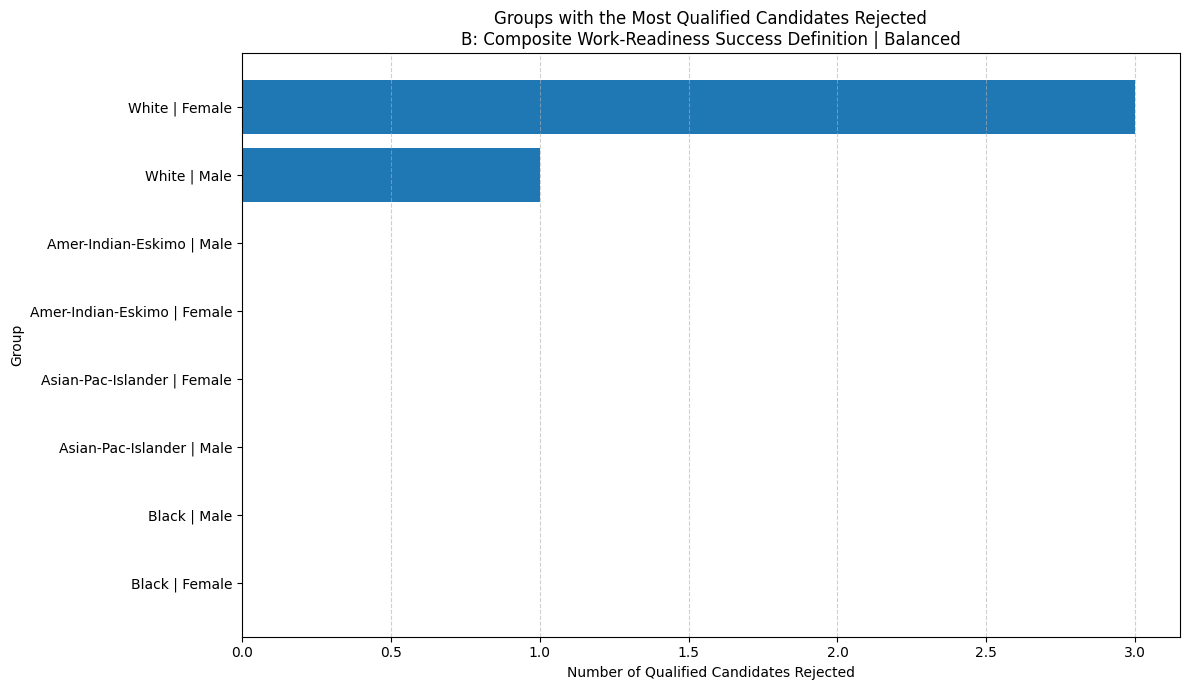

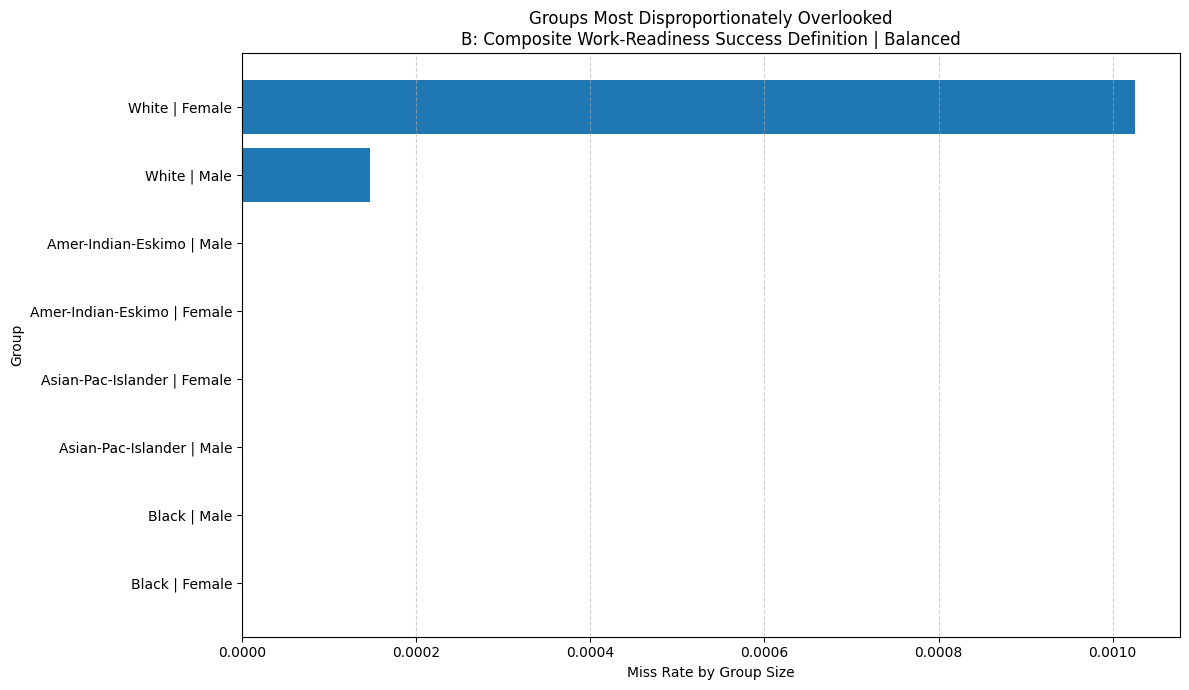

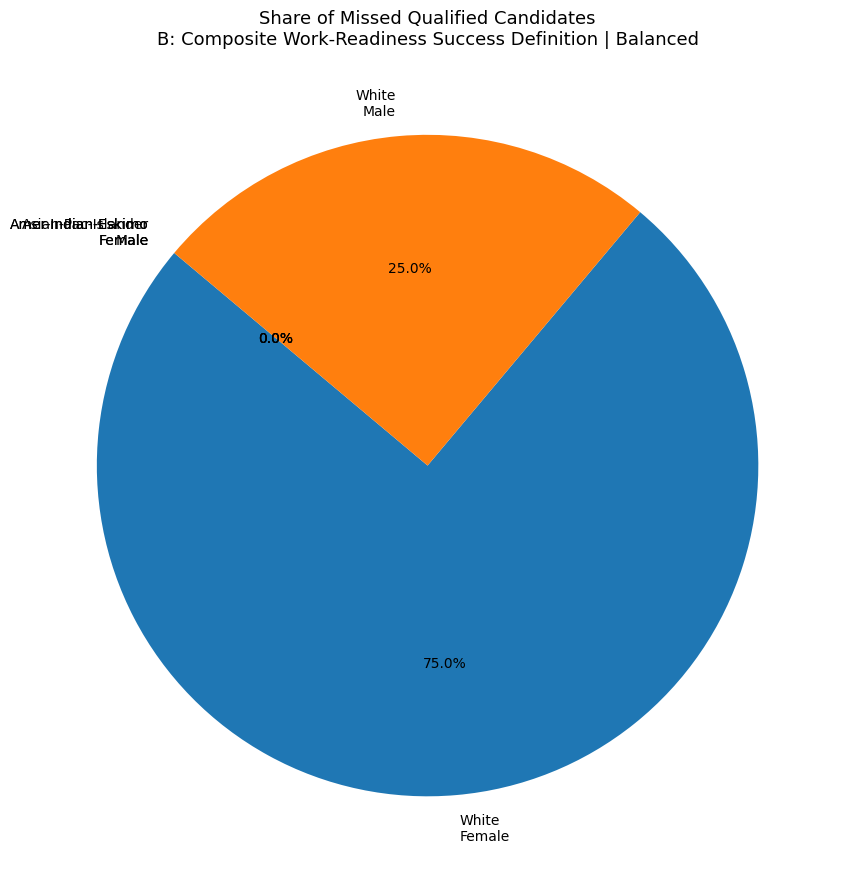

TOP MARGINALIZED GROUPS: B: Composite Work-Readiness Success Definition | Balanced


,group,sample_size,selected_count,selection_rate,FN_missed_good_candidates,false_negative_rate,miss_rate_by_group_size
8,White | Female,2924,1188,0.406293,3,0.002686,0.001026
9,White | Male,6802,2992,0.439871,1,0.000343,0.000147
1,Amer-Indian-Eskimo | Male,53,12,0.226415,0,0.000000,0.000000
0,Amer-Indian-Eskimo | Female,48,16,0.333333,0,0.000000,0.000000
2,Asian-Pac-Islander | Female,121,59,0.487603,0,0.000000,0.000000
3,Asian-Pac-Islander | Male,220,123,0.559091,0,0.000000,0.000000
5,Black | Male,520,136,0.261538,0,0.000000,0.000000
4,Black | Female,522,147,0.281609,0,0.000000,0.000000


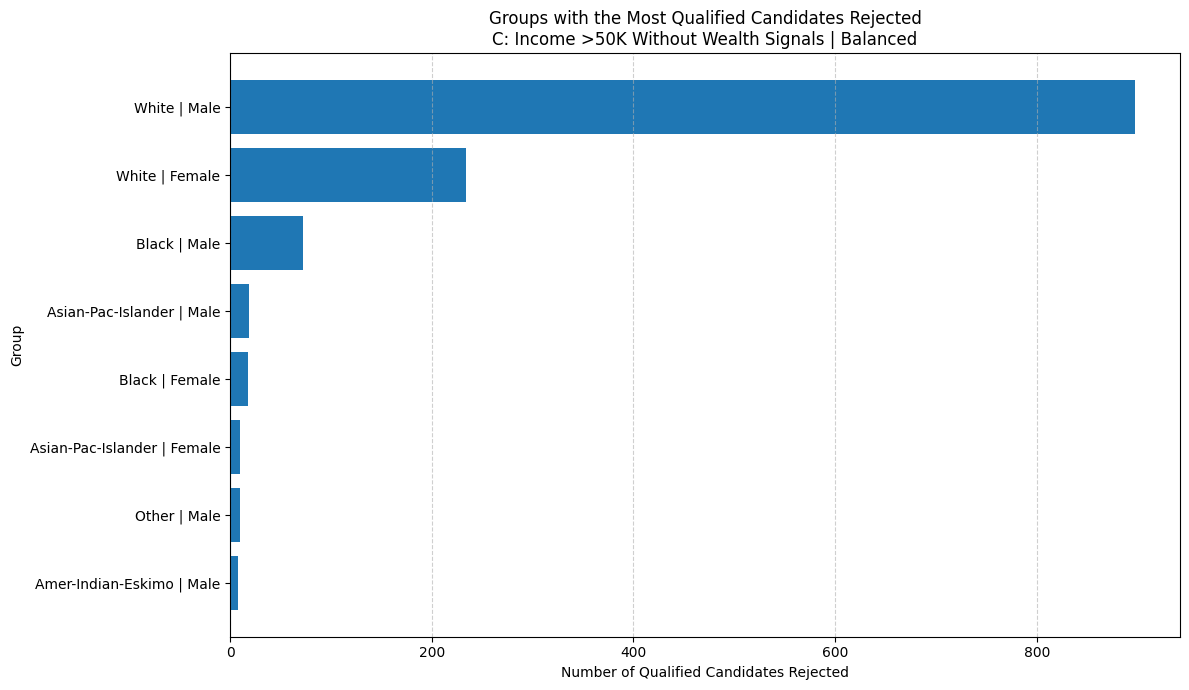

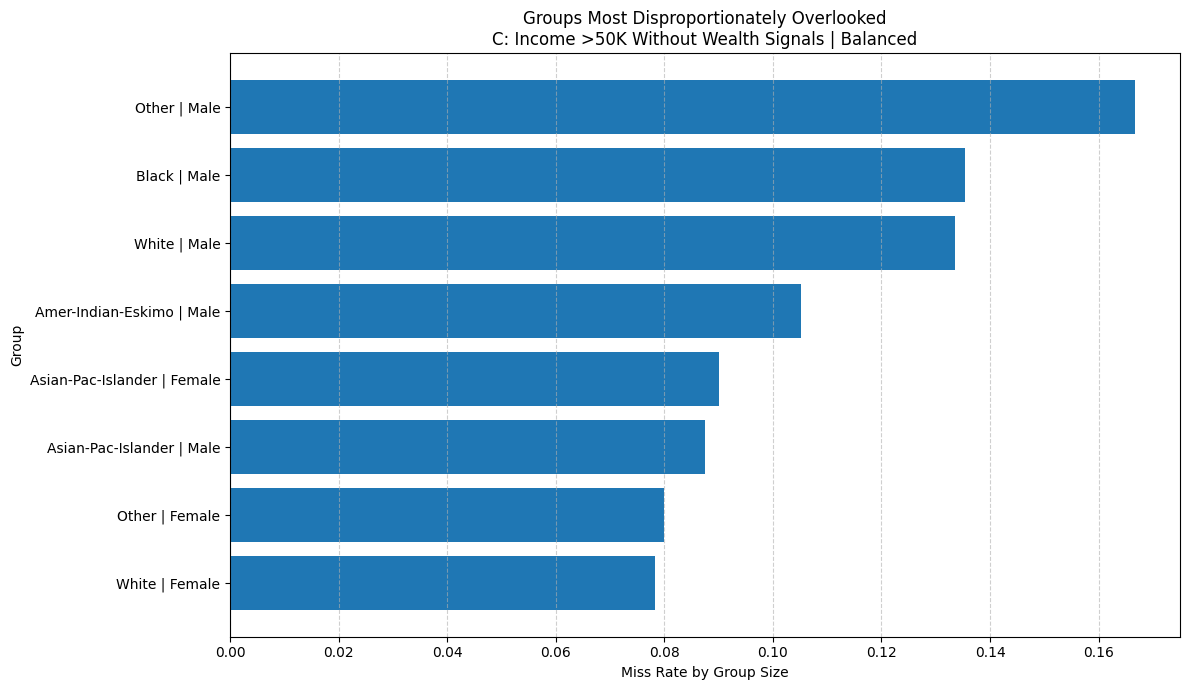

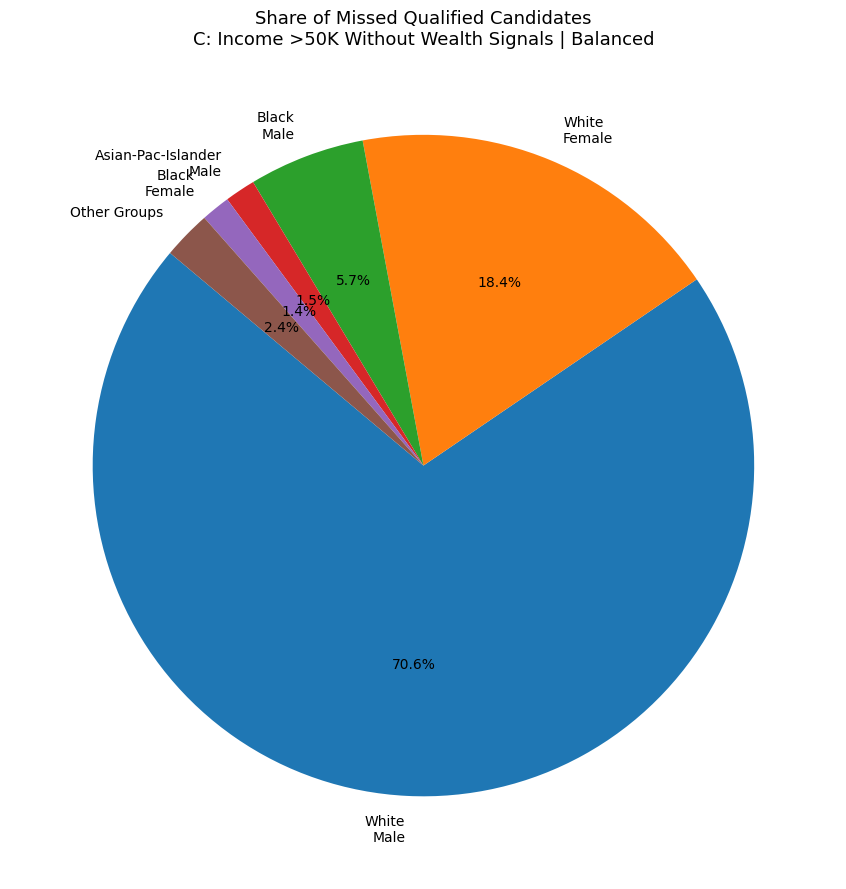

TOP MARGINALIZED GROUPS: C: Income >50K Without Wealth Signals | Balanced


,group,sample_size,selected_count,selection_rate,FN_missed_good_candidates,false_negative_rate,miss_rate_by_group_size
7,Other | Male,60,4,0.066667,10,0.833333,0.166667
5,Black | Male,532,49,0.092105,72,0.720000,0.135338
9,White | Male,6721,1832,0.272578,897,0.412793,0.133462
1,Amer-Indian-Eskimo | Male,76,6,0.078947,8,0.800000,0.105263
2,Asian-Pac-Islander | Female,111,12,0.108108,10,0.555556,0.090090
3,Asian-Pac-Islander | Male,217,72,0.331797,19,0.267606,0.087558
6,Other | Female,25,0,0.000000,2,1.000000,0.080000
8,White | Female,2986,231,0.077361,234,0.603093,0.078366


In [17]:
 # ============================================================
# CLEAN MARGINALIZATION VISUALS
# ============================================================

def clean_marginalization_visuals(group_metrics, experiment_name, policy_name="Balanced", top_n=8):
    """
    Creates readable graphs showing which groups are most marginalized.

    Marginalization is shown in two ways:
    1. Raw missed candidates = total qualified candidates rejected
    2. Miss rate = qualified rejected candidates divided by group size

    Raw count shows total impact.
    Miss rate shows disproportionate impact.
    """

    data = group_metrics.copy()

    # Prevent divide-by-zero issues
    data["miss_rate_by_group_size"] = (
        data["FN_missed_good_candidates"] / data["sample_size"]
    )

    # Sort by raw missed qualified candidates
    raw_sorted = data.sort_values(
        by="FN_missed_good_candidates",
        ascending=False
    ).head(top_n)

    # Sort by miss rate
    rate_sorted = data.sort_values(
        by="miss_rate_by_group_size",
        ascending=False
    ).head(top_n)

    # ------------------------------------------------------------
    # Graph 1: Raw number of qualified candidates rejected
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 7))

    plt.barh(
        raw_sorted["group"],
        raw_sorted["FN_missed_good_candidates"]
    )

    plt.xlabel("Number of Qualified Candidates Rejected")
    plt.ylabel("Group")
    plt.title(
        f"Groups with the Most Qualified Candidates Rejected\n"
        f"{experiment_name} | {policy_name}"
    )

    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Graph 2: Disproportionate marginalization rate
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 7))

    plt.barh(
        rate_sorted["group"],
        rate_sorted["miss_rate_by_group_size"]
    )

    plt.xlabel("Miss Rate by Group Size")
    plt.ylabel("Group")
    plt.title(
        f"Groups Most Disproportionately Overlooked\n"
        f"{experiment_name} | {policy_name}"
    )

    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Graph 3: Clean pie chart with top groups + Other
    # ------------------------------------------------------------
    pie_data = data.sort_values(
        by="FN_missed_good_candidates",
        ascending=False
    ).copy()

    top_pie = pie_data.head(5).copy()
    other_sum = pie_data["FN_missed_good_candidates"].iloc[5:].sum()

    if other_sum > 0:
        other_row = pd.DataFrame({
            "group": ["Other Groups"],
            "FN_missed_good_candidates": [other_sum]
        })

        top_pie = pd.concat(
            [top_pie[["group", "FN_missed_good_candidates"]], other_row],
            ignore_index=True
        )

    labels = top_pie["group"].str.replace(" | ", "\n", regex=False)

    plt.figure(figsize=(9, 9))

    plt.pie(
        top_pie["FN_missed_good_candidates"],
        labels=labels,
        autopct="%1.1f%%",
        startangle=140,
        textprops={"fontsize": 10}
    )

    plt.title(
        f"Share of Missed Qualified Candidates\n"
        f"{experiment_name} | {policy_name}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Table: top marginalized groups
    # ------------------------------------------------------------
    summary_table = data[[
        "group",
        "sample_size",
        "selected_count",
        "selection_rate",
        "FN_missed_good_candidates",
        "false_negative_rate",
        "miss_rate_by_group_size"
    ]].sort_values(
        by="miss_rate_by_group_size",
        ascending=False
    )

    print("=" * 90)
    print(f"TOP MARGINALIZED GROUPS: {experiment_name} | {policy_name}")
    print("=" * 90)

    display(summary_table.head(top_n))

    return summary_table


# ============================================================
# RUN CLEAN VISUALS FOR EACH EXPERIMENT
# ============================================================

marginalized_income = detailed_metrics(results_income, "Balanced", "race_sex")
marginalized_composite = detailed_metrics(results_composite, "Balanced", "race_sex")
marginalized_no_wealth = detailed_metrics(results_no_wealth, "Balanced", "race_sex")

income_marginalization_summary = clean_marginalization_visuals(
    marginalized_income,
    "A: Income >50K Success Definition",
    policy_name="Balanced",
    top_n=8
)

composite_marginalization_summary = clean_marginalization_visuals(
    marginalized_composite,
    "B: Composite Work-Readiness Success Definition",
    policy_name="Balanced",
    top_n=8
)

no_wealth_marginalization_summary = clean_marginalization_visuals(
    marginalized_no_wealth,
    "C: Income >50K Without Wealth Signals",
    policy_name="Balanced",
    top_n=8
)